# Analysis V1.5

# Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Data Loading

In [ ]:
df_all = pd.read_csv("<PRIVATE_DATA_PATH>")

In [3]:
df_all.head()

,Model_Info,Model,horizon_year,label_method,controlled_experiment,Overall C-index,AUC @1y,PR-AUC @1y,C-index @1y,AUC @2y,...,C-index @2y,AUC @3y,PR-AUC @3y,C-index @3y,AUC @4y,PR-AUC @4y,C-index @4y,AUC @5y,PR-AUC @5y,C-index @5y
0,CoxPH,CoxPH,1,classic_survival,False,0.677,0.608,0.183,0.525,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LinearCox Run1,LinearCox,1,classic_survival,False,0.652,0.592,0.173,0.507,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LinearCox Run2,LinearCox,1,classic_survival,False,0.660,0.609,0.183,0.544,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LinearCox Run3,LinearCox,1,classic_survival,False,0.653,0.623,0.202,0.521,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LinearCox Run4,LinearCox,1,classic_survival,False,0.645,0.640,0.202,0.535,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_all["Model"].value_counts()

Model
LinearCox    250
MLP          250
IMAGE        250
FUSION       250
CoxPH         25
XGB           10
Name: count, dtype: int64

# Helper Methods

## df slice

In [5]:
def filter_rows(df, model=None, method=None, year=None, controlled=None):
    """
    General row-filtering utility.
    Any argument = None → skip that filter.
    """
    out = df.copy()

    if model is not None:
        out = out[out["Model"] == model]

    if method is not None:
        out = out[out["label_method"] == method]

    if year is not None:
        out = out[out["horizon_year"] == year]

    if controlled is not None:
        out = out[out["controlled_experiment"] == controlled]

    return out

def metric_cols_for_year(year):
    return [
        f"AUC @{year}y",
        f"PR-AUC @{year}y",
        f"C-index @{year}y",
    ]

def keep_metrics_for_year(df, year):
    base_cols = ["Model_Info", "Model", "label_method", 
                 "controlled_experiment", "horizon_year"]
    return df[base_cols + metric_cols_for_year(year)].copy()

def metric_cols_all_years():
    cols = []
    for y in range(1, 6):
        cols += metric_cols_for_year(y)
    return cols

def get_subset(
    df,
    model=None,
    label=None,
    horizon_year=None,
    controlled=None,
    metrics_for_year=None,   # integer year (1–5) or None
    metrics_all_years=False, # if True → return all metric columns
):
    """
    Combined filtering + column selection helper.

    Parameters
    ----------
    model : str or None
    method : str or None
    year : int or None
    controlled : bool or None
    metrics_for_year : int or None
        If provided → keep only metric columns for that specific horizon.
    metrics_all_years : bool
        If True → keep all year-specific metric columns.

    If neither metrics_for_year nor metrics_all_years is provided,
    the function returns all original columns.
    """

    # -----------------------
    # Step 1 — Row filtering
    # -----------------------
    out = filter_rows(df, model=model, method=label, year=horizon_year, controlled=controlled)

    # -----------------------
    # Step 2 — Column filtering
    # -----------------------

    # Case A: keep metrics for one specific horizon year
    if metrics_for_year is not None:
        return keep_metrics_for_year(out, metrics_for_year)

    # Case B: keep all metric columns across 1y–5y
    if metrics_all_years:
        base_cols = ["Model_Info", "Model", "label_method",
                     "controlled_experiment", "horizon_year"]
        return out[base_cols + metric_cols_all_years()].copy()

    # Case C: keep all columns (default)
    return out


## Plot functions

In [6]:
MODEL_COLORS = {
    "CoxPH":     "#E1D9F2",  # light purple
    "LinearCox": "#F3DDC8",  # light orange / sand
    "MLP":       "#D6E2F0",  # light blue
    "XGB":       "#DCEFE3",  # light green
    "IMAGE":     "#D6ECF3",  # light cyan / imaging #"#F4D6D6",  # light red / pink
    "FUSION":    "#F6E4B8",  # light gold (updated, distinct from LinearCox)
}

MODEL_MARKERS = {
    "XGB":       "o",   # circle
    "CoxPH":     "s",   # square
    "LinearCox": "^",   # triangle
    "MLP":       "D",   # diamond
    "IMAGE":     "P",   # plus-filled
    "FUSION":    "X",   # x-filled
}

EXP_COLORS = {
    ("classic_survival", False): "#000000",  # black
    ("classic_survival", True):  "#1F77B4",  # deep blue
    ("fixed_window_survival", False): "#B22222",  # firebrick red
    ("fixed_window_survival", True):  "#228B22",  # forest green
    ("optimistic_window_survival", False): "#6A0DAD",  # deep purple
}


EXP_LABEL_NAMES = {
    ("classic_survival", False): "Classic (Uncontrolled)",
    ("classic_survival", True):  "Classic (Controlled)",
    ("fixed_window_survival", False): "Fixed_window (Uncontrolled)",
    ("fixed_window_survival", True):  "Fixed_window (Controlled)",
    ("optimistic_window_survival", False): "Optimistic_window (Uncontrolled)",
}

EXP_MARKERS = {
    ("classic_survival", False): "o",   # circle
    ("classic_survival", True):  "s",   # square
    ("fixed_window_survival", False): "^",  # triangle
    ("fixed_window_survival", True):  "D",  # diamond
    ("optimistic_window_survival", False): "X",
}

EXP_SETS = list(EXP_COLORS.keys())

def compute_global_y_range(df, metric="AUC"):
    auc_cols = [c for c in df.columns if c.startswith(metric)]
    vals = np.concatenate([df[c].dropna().values for c in auc_cols])
    mn, mx = vals.min(), vals.max()
    pad = (mx - mn) * 0.05
    return mn - pad, mx + pad

MODEL_ORDER = ["XGB", "CoxPH", "LinearCox", "MLP", "IMAGE", "FUSION"]


In [7]:
def plot_single_model_horizon(df, auc_year, model_horizon,
                              metric="AUC", y_min=0.5, y_max=0.9):
    """
    Plots one figure for a given model-horizon (1,2,3,4,5,0).
    Guarantees consistent x-axis spacing even when experiment sets are missing.
    """
    marker_overlays = [] 
    median_lines = []   # (x, y)

    metric_col = f"{metric} @{auc_year}y"
    if metric_col not in df.columns:
        print(f"[ERROR] Column {metric_col} missing.")
        return

    # ---- Subset rows for this specific horizon ----
    df_h = df[df["horizon_year"] == model_horizon]
    if df_h.empty:
        print(f"[SKIP] Horizon {model_horizon}: no rows")
        return

    # ===========================================
    # FIXED GROUP LAYOUT (Issue 4 + Issue 5)
    # ===========================================
    group_size = len(EXP_SETS) + 1     # 4 experiment sets + 1 blank gap = 5

    data = []
    positions = []
    facecolors = []
    edgecolors = []

    # For every model, allocate all 4 internal slots (even if empty)
    for model_index, model in enumerate(MODEL_ORDER):

        base = model_index * group_size
        df_m = df_h[df_h["Model"] == model]

        for j, (lab, ctrl) in enumerate(EXP_SETS):
            pos = base + j
            positions.append(pos)

            # Model absent → empty slot
            if df_m.empty:
                data.append(None)
                facecolors.append(None)
                edgecolors.append(None)
                continue

            # Experiment-set missing → empty slot
            df_s = df_m[(df_m["label_method"] == lab) &
                        (df_m["controlled_experiment"] == ctrl)]
            if df_s.empty:
                data.append(None)
                facecolors.append(None)
                edgecolors.append(None)
                continue

            # vals = df_s[metric_col].dropna().values
            vals = df_s[metric_col].dropna().values
            # is_degenerate = (len(vals) <= 1) or (np.std(vals) < 1e-4) #change11
            # Case 0: no data at all → skip
            if len(vals) == 0:
                data.append(None)
                facecolors.append(None)
                edgecolors.append(None)
                continue

            # Case 1: degenerate (single / constant) → marker
            is_degenerate = (len(vals) == 1) or (np.std(vals) < 1e-4)
            if is_degenerate:
                marker_overlays.append((
                    pos,
                    np.median(vals),
                    EXP_MARKERS[(lab, ctrl)],
                    EXP_COLORS[(lab, ctrl)],
                    MODEL_COLORS.get(model, "#E8E8E8"),
                ))
                median_lines.append((pos, np.median(vals)))

            if len(vals) == 0:
                data.append(None)
                facecolors.append(None)
                edgecolors.append(None)
                continue

            # Valid data
            data.append(vals)
            # facecolors.append("#E8E8E8")
            facecolors.append(MODEL_COLORS.get(model, "#E8E8E8"))
            edgecolors.append(EXP_COLORS[(lab, ctrl)])

    # Filter out None before plotting (matplotlib cannot handle them)
    plot_data = []
    plot_positions = []
    plot_facecolors = []
    plot_edgecolors = []

    for vals, pos, fc, ec in zip(data, positions, facecolors, edgecolors):
        if vals is None:
            continue
        plot_data.append(vals)
        plot_positions.append(pos)
        plot_facecolors.append(fc)
        plot_edgecolors.append(ec)

    if len(plot_data) == 0:
        print(f"[SKIP] Horizon {model_horizon}: all slots empty")
        return
    
    # ===========================================
    # Dynamic Y-axis range (restore visibility)
    # ===========================================
    if len(plot_data) > 0:
        all_vals = np.concatenate([v for v in plot_data])
        ymin_local = all_vals.min()
        ymax_local = all_vals.max()
        pad = (ymax_local - ymin_local) * 0.05

        y_min = ymin_local - pad
        y_max = ymax_local + pad

    # ===========================================
    # Boxplot drawing
    # ===========================================
    plt.figure(figsize=(14, 5))

    bp = plt.boxplot(
        plot_data,
        positions=plot_positions,
        patch_artist=True,
        widths=0.6,
        showfliers=True,
    )

    #change11

    for x, y in median_lines:
        plt.hlines(
            y,
            x - 0.3, x + 0.3,
            color="#E69F00",  # same orange as box medians
            linewidth=2,
            zorder=4,
        )

    for x, y, mk, ec, fc in marker_overlays:
        plt.scatter(
            x, y,
            marker=mk,
            s=80,
            facecolor=fc,
            edgecolor=ec,
            linewidth=1.8,
            zorder=3,
        )

    # color each box
    for box, fc, ec in zip(bp["boxes"], plot_facecolors, plot_edgecolors):
        box.set_facecolor(fc)
        box.set_edgecolor(ec)
        box.set_linewidth(2)

    # ===========================================
    # X-axis grouping (FINAL + CORRECT)
    # ===========================================
    group_centers = [
        i * group_size + (len(EXP_SETS) - 1) / 2  # center of 4 slots
        for i in range(len(MODEL_ORDER))
    ]

    plt.xticks(group_centers, MODEL_ORDER)

    # ===========================================
    # Title, y-range
    # ===========================================
    plt.ylim(y_min, y_max)
    plt.title(f"AUC Distribution @ {auc_year}y\nModel Horizon = {model_horizon}")
    plt.ylabel(metric_col)

    # ===========================================
    # Legend (uses EXP_COLORS)
    # ===========================================
    # legend_patches = [
    #     Patch(edgecolor=EXP_COLORS[(lab, ctrl)], facecolor="#E0E0E0",
    #           label=f"{lab}, controlled={ctrl}")
    #     for (lab, ctrl) in EXP_SETS
    # ]
    legend_patches = [
        Patch(
            edgecolor=EXP_COLORS[(lab, ctrl)],
            facecolor="#E0E0E0",
            label=EXP_LABEL_NAMES[(lab, ctrl)]
        )
        for (lab, ctrl) in EXP_SETS
    ]

    plt.legend(handles=legend_patches, title="Experiment Sets")

    # ===========================================
    # FORCE x-axis limits to prevent right-shift
    # ===========================================
    total_groups = len(MODEL_ORDER)
    x_min = -0.5
    x_max = total_groups * group_size - 0.5
    plt.xlim(x_min, x_max)


    plt.tight_layout()
    plt.show()

In [8]:
def get_auc_summary_table(df, auc_year, model_horizon, metric="AUC"):
    """
    Returns a table of (Q1, Median, Q3) for each model and experiment set,
    matching the boxplot structure used in your plotting function.
    """

    metric_col = f"{metric} @{auc_year}y"
    if metric_col not in df.columns:
        raise ValueError(f"Missing metric column: {metric_col}")

    # filter by horizon
    df_h = df[df["horizon_year"] == model_horizon]

    rows = []

    for model in MODEL_ORDER:
        df_m = df_h[df_h["Model"] == model]

        row = {"Model": model}

        for (lab, ctrl) in EXP_SETS:

            df_s = df_m[(df_m["label_method"] == lab) &
                        (df_m["controlled_experiment"] == ctrl)]

            vals = df_s[metric_col].dropna().values

            if len(vals) == 0:
                row[f"{lab},{ctrl}"] = None
            else:
                q1 = np.percentile(vals, 25)
                med = np.percentile(vals, 50)
                q3 = np.percentile(vals, 75)
                row[f"{lab},{ctrl}"] = (round(q1,4), round(med,4), round(q3,4))

        rows.append(row)

    if model_horizon == 0:
        print("\n[NOTE] For model_horizon = 0 (ANY): optimistic label methods "
            "fallback to horizon=5. Only classic label results reflect true "
            "ANY-horizon training.\n")

    return pd.DataFrame(rows)

In [9]:
def plot_auc_year(df, auc_year, metric="AUC", y_min=None, y_max=None):
    """
    Plots all model-horizon groups that can evaluate AUC@auc_year.
    Horizon 0 (formerly 'any') is always plotted last.
    """

    # compute y-range if needed
    if y_min is None or y_max is None:
        y_min, y_max = compute_global_y_range(df, metric=metric)

    # extract available horizons
    raw_horizons = sorted(set(df["horizon_year"].unique()))

    # horizons that can predict auc_year:
    #    - numeric horizon >= auc_year
    #    - horizon 0 ("any"), always included
    eligible = []
    for h in raw_horizons:
        if h == 0:          # 'any'
            eligible.append(0)
        elif h >= auc_year:
            eligible.append(h)

    # enforce plotting order 1,2,3,4,5,..., then 0 last
    ordered = sorted([h for h in eligible if h != 0])  # numeric horizons in ascending order
    if 0 in eligible:
        ordered.append(0)

    print(f"[DEBUG] AUC@{auc_year}: plotting horizons → {ordered}")

    for horizon in ordered:
        plot_single_model_horizon(
            df=df,
            auc_year=auc_year,
            model_horizon=horizon,
            metric=metric,
            y_min=y_min,
            y_max=y_max,
        )


In [10]:
from matplotlib.lines import Line2D

def plot_median_auc_trend(
    df,
    auc_year,
    metric="AUC",
    horizons=(1, 2, 3, 4, 5),
    concise_legend=False,
):
    """
    Line plot of median AUC@{auc_year}y vs model horizon.

    Encoding:
      - Marker shape : Model
      - Line color   : Experiment set
    """

    metric_col = f"{metric} @{auc_year}y"
    if metric_col not in df.columns:
        raise ValueError(f"Column {metric_col} not found in df")

    plt.figure(figsize=(10, 6))

    full_handles = {}

    # ---------------- plot lines ----------------
    for model in MODEL_ORDER:
        df_m = df[df["Model"] == model]
        if df_m.empty:
            continue

        for (lab, ctrl) in EXP_SETS:
            xs, ys = [], []

            for h in horizons:
                df_h = df_m[
                    (df_m["horizon_year"] == h) &
                    (df_m["label_method"] == lab) &
                    (df_m["controlled_experiment"] == ctrl)
                ]

                if df_h.empty:
                    continue

                vals = df_h[metric_col].dropna().values
                if len(vals) == 0:
                    continue

                xs.append(h)
                ys.append(np.median(vals))

            if len(xs) == 0:
                continue

            line, = plt.plot(
                xs,
                ys,
                marker=MODEL_MARKERS.get(model, "o"),
                linestyle="-",
                linewidth=2,
                markersize=7,
                color=EXP_COLORS[(lab, ctrl)],
            )

            if not concise_legend:
                label = f"{model} | {EXP_LABEL_NAMES[(lab, ctrl)]}"
                full_handles[label] = line

    # ---------------- axes ----------------
    plt.xlabel("Model Horizon (years)")
    plt.ylabel(f"Median {metric} @ {auc_year}y")
    plt.title(f"Median {metric} @ {auc_year}y vs Model Horizon")
    plt.xticks(horizons)
    plt.grid(True, linestyle="--", alpha=0.4)

    # ---------------- legends ----------------
    if concise_legend:
        # Model legend (markers)
        model_handles = [
            Line2D(
                [0], [0],
                marker=MODEL_MARKERS[m],
                linestyle="None",
                markersize=8,
                markerfacecolor="gray",
                markeredgecolor="black",
                label=m,
            )
            for m in MODEL_ORDER
        ]

        # Experiment-set legend (colors)
        exp_handles = [
            Line2D(
                [0], [0],
                color=EXP_COLORS[(lab, ctrl)],
                linewidth=3,
                label=EXP_LABEL_NAMES[(lab, ctrl)],
            )
            for (lab, ctrl) in EXP_SETS
        ]

        # -------- combined legend (model markers + experiment colors) --------
        combined_handles = []

        # model entries (markers only)
        for m in MODEL_ORDER:
            combined_handles.append(
                Line2D(
                    [0], [0],
                    marker=MODEL_MARKERS[m],
                    linestyle="None",
                    markersize=8,
                    markerfacecolor="gray",
                    markeredgecolor="black",
                    label=f"Model: {m}",
                )
            )

        # experiment-set entries (colors only)
        for (lab, ctrl) in EXP_SETS:
            combined_handles.append(
                Line2D(
                    [0], [0],
                    color=EXP_COLORS[(lab, ctrl)],
                    linewidth=3,
                    label=f"Exp: {EXP_LABEL_NAMES[(lab, ctrl)]}",
                )
            )

        plt.legend(
            handles=combined_handles,
            frameon=True,
        )


    else:
        plt.legend(
            full_handles.values(),
            full_handles.keys(),
            fontsize=9,
            ncol=2,
            title="Model | Experiment Set",
        )

    plt.tight_layout()
    plt.show()


In [11]:
def final_plot2(label_method = "classic_survival", ctrl = True, horizon_year=5):
    MODEL_COLORS_FINAL = {
        "CoxPH":     "#7A6FB0",  # deeper purple (from #E1D9F2)
        "LinearCox": "#D08A3B",  # deeper sand / orange (from #F3DDC8)
        "MLP":       "#4F7FBF",  # deeper blue (from #D6E2F0)
        "XGB":       "#4FA87A",  # deeper green (from #DCEFE3)
        "IMAGE":     "#4AA3B5",  # deeper cyan (from #D6ECF3)
        "FUSION":    "#C49A00",  # deep gold / amber (updated)
    }

    plt.figure(figsize=(8, 5))

    for model in MODEL_ORDER:
        if model == "XGB":
            df_m = df_all[
                (df_all["Model"] == "XGB") &
                (df_all["label_method"] == "fixed_window_survival") &
                (df_all["controlled_experiment"] == True)
            ]
        else:
            df_m = df_all[
                (df_all["Model"] == model) &
                (df_all["label_method"] == label_method) &
                (df_all["controlled_experiment"] == ctrl) &
                (df_all["horizon_year"] == horizon_year)
            ]

        if df_m.empty:
            continue

        xs, ys = [], []
        for n in [1, 2, 3, 4, 5]:
            col = f"AUC @{n}y"
            if col not in df_m.columns:
                continue
            vals = df_m[col].dropna().values
            if len(vals) == 0:
                continue
            xs.append(n)
            ys.append(np.median(vals))

        if len(xs) == 0:
            continue

        plt.scatter(
            xs,
            ys,
            s=90,
            color=MODEL_COLORS_FINAL.get(model, "#999999"),
            edgecolor="black",
            linewidth=0.8,
            alpha=0.9,
            label=model,
            zorder=3,
        )

    plt.xticks([1, 2, 3, 4, 5])
    plt.xlabel("Evaluation Horizon (years)")
    plt.ylabel("AUC")

    plt.title(
        "Model Comparison under Best Experiment Setup\n"
        "Classic Survival + Controlled (Training Horizon = 5y)"
    )

    plt.grid(alpha=0.3)

    # Deduplicate legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title="Model")

    plt.tight_layout()
    plt.show()

In [12]:
def final_plot1(label_method = "classic_survival", ctrl = True, horizon_year=5):
    # ------------------------------
    # Settings
    # ------------------------------
    auc_years = [1, 2, 3, 4, 5]

    # ------------------------------
    # Prepare figure
    # ------------------------------
    plt.figure(figsize=(8, 5))

    for model in MODEL_ORDER:
        # --------------------------
        # Special handling for XGB
        # --------------------------
        if model == "XGB":
            df_m = df_all[
                (df_all["Model"] == "XGB") &
                (df_all["label_method"] == "fixed_window_survival") &
                (df_all["controlled_experiment"] == True)
            ]
        else:
            df_m = df_all[
                (df_all["Model"] == model) &
                (df_all["label_method"] == label_method) &
                (df_all["controlled_experiment"] == ctrl) &
                (df_all["horizon_year"] == horizon_year)
            ]

        if df_m.empty:
            continue

        xs, ys = [], []

        for n in auc_years:
            col = f"AUC @{n}y"
            if col not in df_m.columns:
                continue

            vals = df_m[col].dropna().values
            if len(vals) == 0:
                continue

            xs.append(n)
            ys.append(np.median(vals))

        if len(xs) == 0:
            continue

        plt.plot(
            xs,
            ys,
            marker="o",
            linewidth=2,
            label=model,
            color=MODEL_COLORS.get(model, "#333333"),
        )

    # ------------------------------
    # Final formatting
    # ------------------------------
    plt.xticks(auc_years)
    plt.xlabel("Evaluation Horizon (years)")
    plt.ylabel("AUC")

    plt.title(
        "Model Comparison under Best Experiment Setup\n"
        "Classic Survival + Controlled (Horizon = 5y)"
    )

    plt.legend(title="Model")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Analysis

**Note1**: We have 3 labelmethod: `classic_survival`, `fixed_window_survival`, `Optimistic_window_survival`, and 2 experiemnt mode: `Controlled`, `Uncontrolled`. (Intuitively we have 3*2=6 experiment setups.)

---

**Note2**: In `Controlled` experiments, both `fixed_window_survival` and `Optimistic_window_survival` will create exactly same label and duration, so we skip training model for `Controlled` & `Optimistic_window_survival` because it is redundant. That explains why in plots below we only have **5** total experiment setups.

---

**Note3**: For `classic_survival` case, the event is defined as "having CP" without consideration of horizon. In this case, XGBoost models cannot make predictions aligned with our objective "how possible a patient get CP with n years" so we skip it. That explains why XGBoost models don't have results for `classic_survival`. In another aspect, `fixed_window_survival` and `Optimistic_window_survival` labeling has exactly same labels but different durations. Because duration was **NOT** used as features, XGBoost models for `fixed_window_survival` and `Optimistic_window_survival` will be the same, so we skip the XGBoost training for `Optimistic_window_survival` due to defundency. By the end, XGBoost models only have **2** results: (`Controlled` & `fixed_window_survival`) and (`Uncontrolled` & `fixed_window_survival`).

---
**Note4**: Unlike surivial models, XGBoost is a classification model can only compute the `AUC@ny` for specifical `n` defined by the horizon. For example, XGBoost have only `AUC@1y` for Model Horizon = 1 and only `AUC@3y` for Model Horizon = 3. 

---

**Note5**: For `classic_survival`:
- `Uncontrolled` & `classic_survival` has same labels and duration for all model horizons, so in the plot we can see no trend, as expected.
- `Controlled` & `classic_survival` has same labels and duration for all model horizons, but `Controlled` will filter out datapoints based on model horizon. So model horizon will impact the dataset size.

## 1. AUC@1y

In [13]:
df_all["label_method"].value_counts()

label_method
fixed_window_survival         420
classic_survival              410
optimistic_window_survival    205
Name: count, dtype: int64

In [14]:
df_all[df_all["label_method"] == "optimistic_window_survival"]["controlled_experiment"].value_counts()

controlled_experiment
False    205
Name: count, dtype: int64

### 1.1 plots

[DEBUG] AUC@1: plotting horizons → [1, 2, 3, 4, 5]


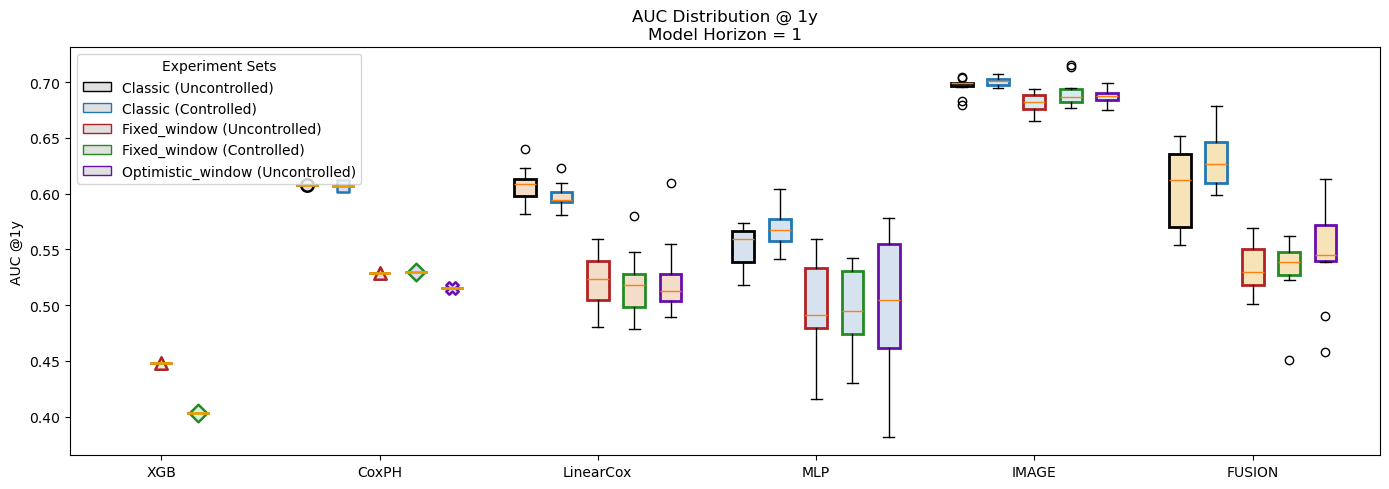

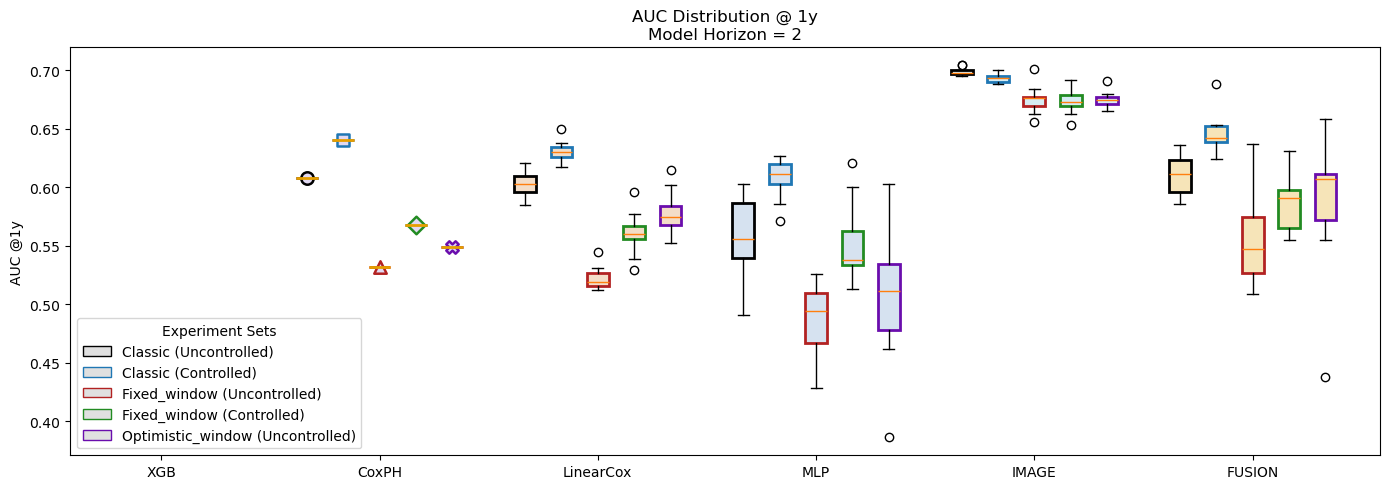

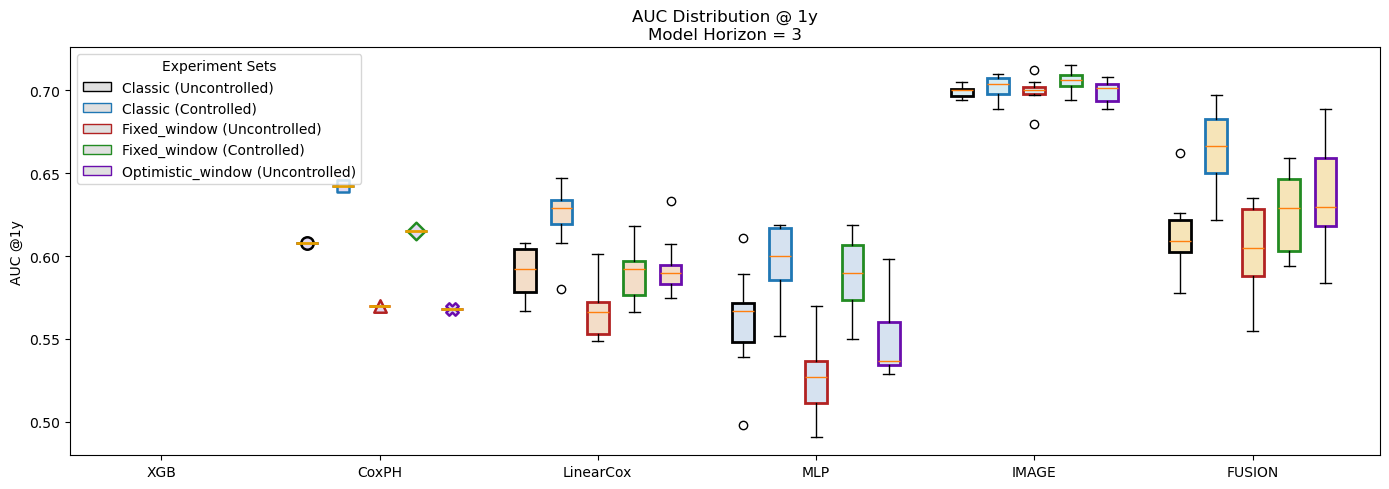

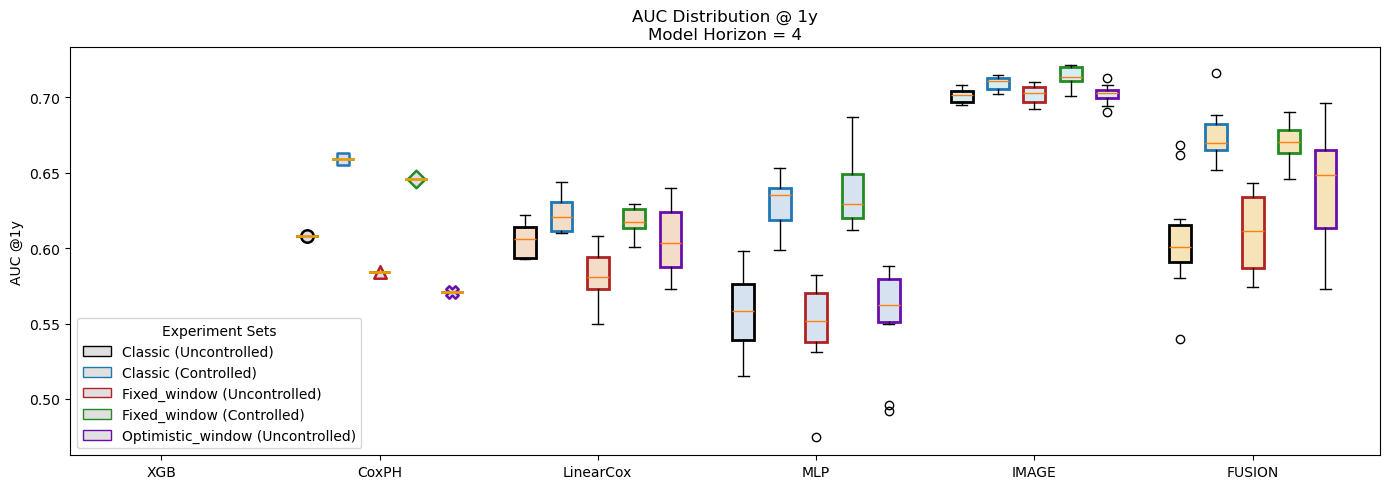

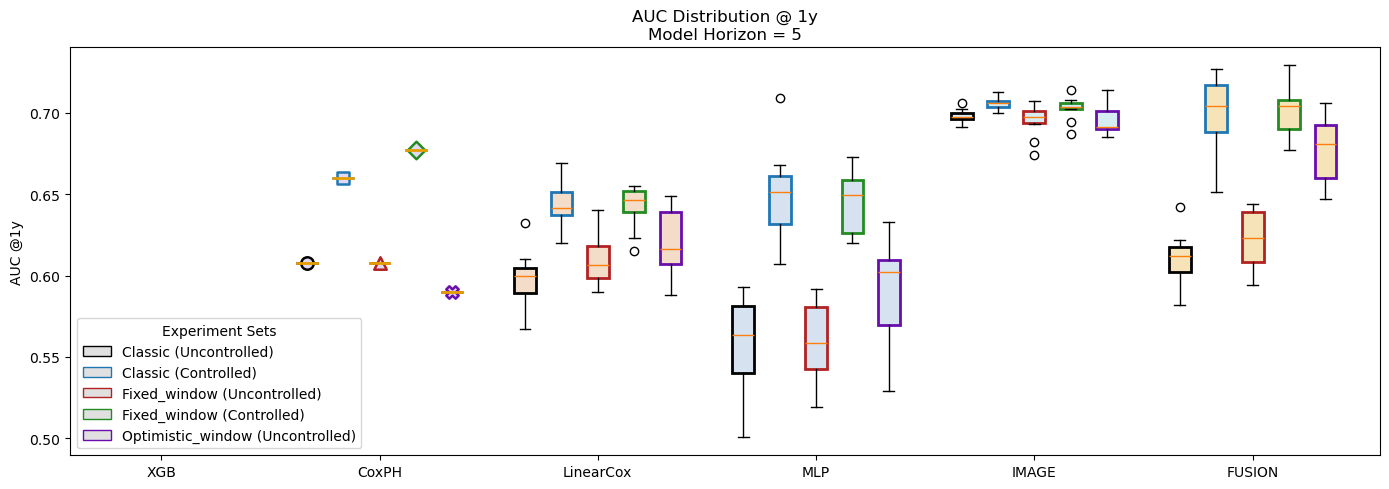

In [15]:
plot_auc_year(df_all, auc_year=1)

### 1.2 Tables

In [16]:
get_auc_summary_table(df_all, auc_year=1, model_horizon=4)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,None,None,None
1,CoxPH,"(0.608, 0.608, 0.608)","(0.659, 0.659, 0.659)","(0.584, 0.584, 0.584)","(0.646, 0.646, 0.646)","(0.571, 0.571, 0.571)"
2,LinearCox,"(0.5935, 0.606, 0.6142)","(0.6112, 0.6205, 0.6305)","(0.573, 0.581, 0.594)","(0.613, 0.6175, 0.6258)","(0.5875, 0.6035, 0.6238)"
3,MLP,"(0.539, 0.5585, 0.576)","(0.6188, 0.635, 0.64)","(0.5378, 0.5515, 0.57)","(0.62, 0.6295, 0.649)","(0.551, 0.5625, 0.5795)"
4,IMAGE,"(0.6968, 0.7015, 0.704)","(0.7058, 0.7105, 0.713)","(0.697, 0.7025, 0.7065)","(0.7108, 0.7135, 0.72)","(0.6998, 0.703, 0.705)"
5,FUSION,"(0.5905, 0.6005, 0.6152)","(0.6652, 0.6695, 0.682)","(0.587, 0.6115, 0.634)","(0.663, 0.6705, 0.6785)","(0.6132, 0.6485, 0.6648)"


In [ ]:
get_auc_summary_table(df_all, auc_year=1, model_horizon=1)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,"(0.448, 0.448, 0.448)","(0.403, 0.403, 0.403)",None
1,CoxPH,"(0.608, 0.608, 0.608)","(0.607, 0.607, 0.607)","(0.529, 0.529, 0.529)","(0.53, 0.53, 0.53)","(0.515, 0.515, 0.515)"
2,LinearCox,"(0.598, 0.6085, 0.6132)","(0.5925, 0.594, 0.6012)","(0.5045, 0.5235, 0.5398)","(0.4982, 0.518, 0.528)","(0.504, 0.5125, 0.5282)"
3,MLP,"(0.5385, 0.5595, 0.5662)","(0.5575, 0.567, 0.577)","(0.4798, 0.4915, 0.5335)","(0.4738, 0.4945, 0.5305)","(0.462, 0.505, 0.555)"
4,IMAGE,"(0.6965, 0.699, 0.699)","(0.6975, 0.701, 0.703)","(0.676, 0.682, 0.6882)","(0.6822, 0.6865, 0.694)","(0.6842, 0.6875, 0.6905)"
5,FUSION,"(0.57, 0.612, 0.636)","(0.6095, 0.627, 0.646)","(0.518, 0.5295, 0.5502)","(0.5275, 0.539, 0.548)","(0.54, 0.545, 0.5718)"


### 1.3 Analysis

#### 1.3.1 model horizon analysis

**Note**: When evaluating AUC at a fixed time point (`AUC@1y`), the evaluation set and the
corresponding meaningful positive and negative cases are identical across all
model horizons. Therefore, the observed performance differences do **not** arise
from changes in evaluation data composition, but from differences in how models
are trained. Specifically, models with different horizons are trained under different event
definitions: predicting whether a patient will develop CP **within n years**.
As the model horizon increases, the training objective captures a broader notion
of CP risk.

We observed that model trained with a large model horizon have improved `AUC@1y`, except (`Uncontrolled` & `classic_survival`). That shows a improved risk discrimination capability. This behavior can be explained by the below: 


Meaningful Point Distribution

| Horizon | Meaningful Pos **respect to horizon** | Meaningful Neg **respect to horizon** | Total Meaningful **respect to horizon** |
|--------:|---------------:|---------------:|-----------------:|
| **1 year** | 67 | 821 | **888** |
| **5 years** | 219 | 293 | **512** |

Reasons for this counter-intuitive situation:
- **Short-horizon training suffers from extreme class imbalance**  
  When training with a 1-year horizon, positive cases are rare (67 positives vs
  821 negatives ≈ 1:12), leading to weak supervision and unstable risk ranking.

- **Longer horizons provide stronger and more balanced supervision**  
  Training with a 5-year horizon substantially increases the number of positive
  events seen during training (total ture positives vs negatives ≈ 10:14) , resulting in a clearer separation between high-
  and low-risk patients. 

- **Long-horizon models learn more generalizable risk patterns**  
  Positive cases at longer horizons include all early CP events as well as later
  progressions, allowing models to learn broader CP risk factors that also
  generalize well to early (1-year) prediction.

Extra: 
- `Uncontrolled` & `classic_survival` has same labels and duration for all model horizons, so in the plot we can see no trend, as expected.

Conclusion:
> We will select models with larger model horizon for better AUC performance.


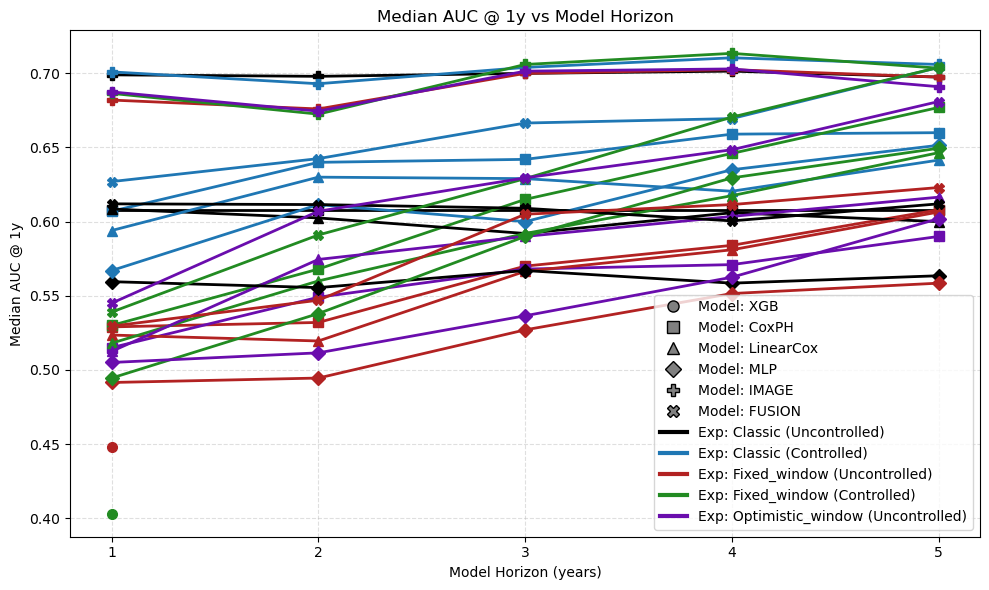

In [18]:
plot_median_auc_trend(df_all, auc_year=1, concise_legend=True)

-----

#### 1.3.2 controlled experiemnt analysis

In [19]:
import numpy as np
import pandas as pd

# ------------------------------
# Settings
# ------------------------------
AUC_COL = "AUC @2y"
MODELS = df_all["Model"].unique()

COLS = [
    ("classic_survival", False),
    ("classic_survival", True),
    ("fixed_window_survival", False),
    ("fixed_window_survival", True),
]

rows = []

for model in MODELS:
    row = {"Model": model}

    for label, ctrl in COLS:
        # XGB special handling
        if model == "XGB":
            if label != "fixed_window_survival":
                row[f"{label},{ctrl}"] = np.nan
                continue

            df_m = df_all[
                (df_all["Model"] == "XGB") &
                (df_all["label_method"] == "fixed_window_survival") &
                (df_all["controlled_experiment"] == ctrl)
            ]
        else:
            df_m = df_all[
                (df_all["Model"] == model) &
                (df_all["label_method"] == label) &
                (df_all["controlled_experiment"] == ctrl)
            ]

        if AUC_COL not in df_m.columns or df_m.empty:
            row[f"{label},{ctrl}"] = np.nan
        else:
            vals = df_m[AUC_COL].dropna().values
            row[f"{label},{ctrl}"] = np.median(vals) if len(vals) > 0 else np.nan

    rows.append(row)

# ------------------------------
# Final DataFrame
# ------------------------------
auc2y_compare_df = pd.DataFrame(rows).set_index("Model")
auc2y_compare_df


,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True"
Model,,,,
CoxPH,0.7040,0.7135,0.6640,0.6800
LinearCox,0.6935,0.6975,0.6755,0.6815
MLP,0.6675,0.6900,0.6515,0.6845
IMAGE,0.6635,0.6655,0.6550,0.6580
FUSION,0.6910,0.7295,0.6760,0.7140
XGB,NaN,NaN,0.5270,0.6830


Across all training model horizons (except for xgb auc@1y), the `Controlled` models consistently outperform their uncontrolled counterparts. This behavior is observed across labeling methods and model
families. In `Controlled` cases, models are trained **only on meaningful datapoints**, i.e., patients whose CP status within the prediction horizon is known. In
contrast, uncontrolled models are trained on **all available datapoints**, including a large number of ambiguous cases with insufficient follow-up. 

For all training horizons, the models with `controlled_experiment=True` consistently outperform the uncontrolled ones.  
The controlled models are trained **only on meaningful datapoints**, while uncontrolled models include **all datapoints**, including thousands of ambiguous cases.  
However, 

Meaningful-Point Distribution (Horizon = 5 years, `classic_survival`)
| Mode                   | Meaningful Pos | Meaningful Neg | Total Meaningful | Ambiguous Points | Total Samples |
|-----------------------|----------------:|----------------:|------------------:|------------------:|---------------:|
| **Uncontrolled** | 219 | 293 | **512** | **1511** | 2023 |
| **Controlled** | 219 | 293 | **512** | **0** | **512** |

Breakdown by split (Train / Val / Test):

| Mode | Train Meaningful | Train Total | Val Meaningful | Val Total | Test Meaningful | Test Total |
|------|------------------:|------------:|----------------:|----------:|-----------------:|-----------:|
| **Uncontrolled**      | 312 | 1213 | 104 | 405 | 96 | 405 |
| **Controlled**  | 312 | 312  | 104 | 104 | 96 | 96 |

Analysis:
- `Uncontrolled` models have much more data to train and many datapoints do provide useful information such as “patient with features X stayed safe for 2 years.” However, such ambiguous datapoints will be labeled as `event=0` because they don't have CP recorded yet. However, if they did obtain CP during horizon without record, such `event=0` will be a wrong label instead, so called **false-negative**. So those ambiguous datapoints impose noise for model learning. 
- Noticing that the number of ambiguous datapoints is dominating in whole dataset, using `Uncontrolled` will mess up the correct risk pattern learned from meaningful datapoints. The disadvatnatges from ambiguous datapoints is over its potential advatantages.
- For `Controlled` cases, models only see the true meangingful datapoints and learn the real discriminative structure of CP progression.

In summary: **Useful data is not necessarily meaningful data, but meaningful data is always useful.**

Conclusion:
> We will select `Controlled` models for better AUC performance. 

----

#### 1.3.3 Uncontrolled labeling analysis

In `Uncontrolled` experiemnts, `fixed_window_survival` performed worse than `Optimistic_window_survival`.

Recap of two label method, in terms of duration.
- **Optimistic-window labeling collapses censoring times.**  
  Nearly all negative cases have their processed duration set exactly to the horizon (e.g., 3 years), eliminating almost all censor-time heterogeneity.

- **Fixed-window labeling preserves censor-time heterogeneity.**  
  Negative cases retain their original follow-up durations, producing a wide and continuous distribution of censoring times from near 0 up to the horizon.

Analysis of plot below:
- most censor-time variability is concentrated below 1 year. Beyond the first year, the density of durations becomes sparse and relatively flat.
- While fixed-window labeling preserves variation in censoring times, much of the
  variability relevant to AUC@1y lies either beyond the 1-year horizon or within
  a narrow range below 1 year, where differences are weakly informative

Reason:

For AUC@1y, the prediction task is to discriminate whether CP occurs **within the first year**. In this setting:

- Patients censored at 0.2 years and 0.8 years are both simply “not observed to develop CP within 1 year.”
- Although fixed-window labeling preserves variation within 0–1 year, this variation is **weakly aligned with the 1-year event boundary**.
- Most censor-time heterogeneity either lies **beyond the 1-year horizon** or is too small in magnitude to provide strong ranking signal for 1-year risk.
- Example: for `AUC@3y`, followup time of 2y will be more meaningful and clearly less risk than followup time of 1y. However, for `AUC@1y`, such difference in risk is not big enough to support risk ranking.
- So instead, the information provided from those high-variance durations become noise, the disadvantge is over the advantage, causing worse performance.

As a result, preserving censor-time heterogeneity does not substantially improve discrimination at AUC@1y.



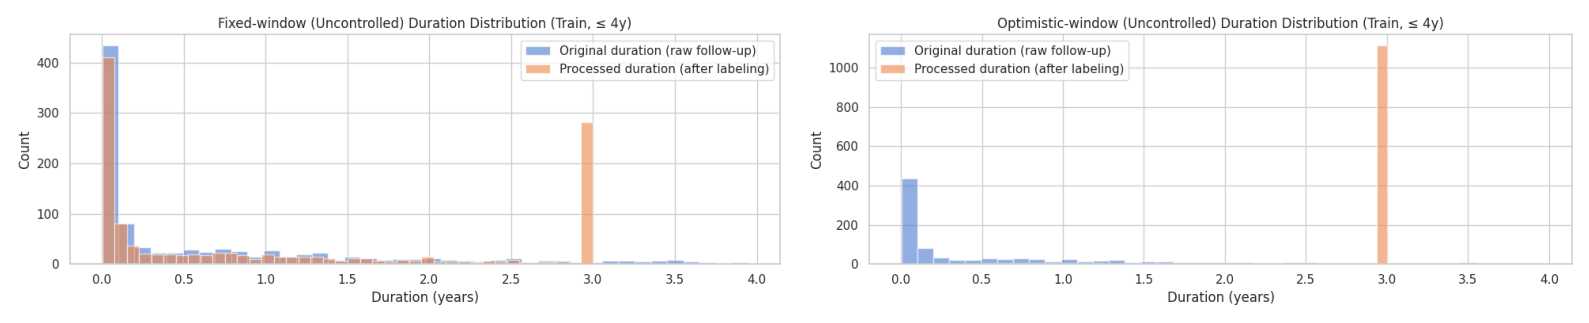

In [20]:
img1 = plt.imread("figures/img1.png")
img2 = plt.imread("figures/img2.png")
plt.figure(figsize=(16,6))

# Left image
plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.axis("off")

# Right image
plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.axis("off")

plt.tight_layout()
plt.show()

----

#### 1.3.4 labeling analysis

Across all evaluation horizons (AUC@1–5y), models trained with
`classic_survival` consistently outperform those trained with
`fixed_window_survival`, in both controlled and uncontrolled settings.

- This occurs because classic survival preserves the full time-to-event
information, including late CP events and fine-grained censoring
heterogeneity. In contrast, fixed-window labeling artificially truncates
follow-up time and reclassifies late CP events as censored negatives,
discarding informative risk signal.

- Although fixed-window labeling more closely matches the downstream task
definition (“CP within *n* years”), it sacrifices statistical efficiency
by collapsing heterogeneous outcomes. Classic survival instead learns a
global risk ordering that generalizes across evaluation horizons.

-----

#### 1.3.5 Model selection

- becuase we observed AUC improve for model trainined with larger horizon, we just select the best in largest horizon (5 or 0).
- because we observed AUC improve for controlled model, we just select the best in controlled models.
- best models for AUC@1y:
    - (IMAGE,fixed_window_survival,true,4) (0.7108, 0.7135, 0.72)	
    - (IMAGE,classic_survival,true,4) (0.7108, 0.7135, 0.72)
    - (FUSION,classic_survival,True,5) (0.688, 0.704, 0.7172)	

________

________

## 2. AUC@2y

### 2.1 plots

[DEBUG] AUC@2: plotting horizons → [2, 3, 4, 5]


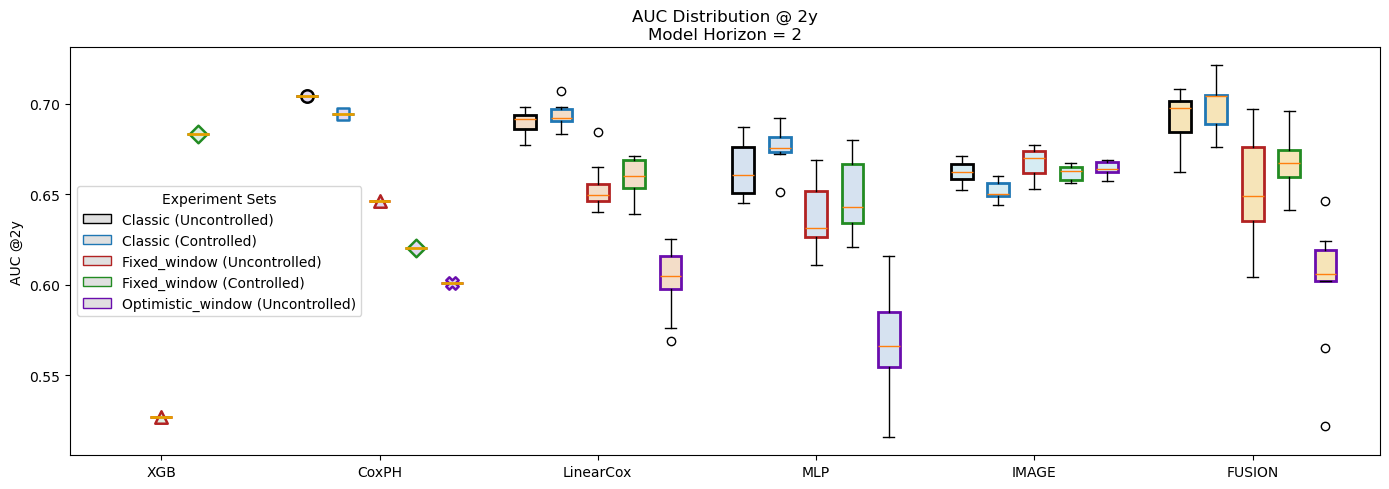

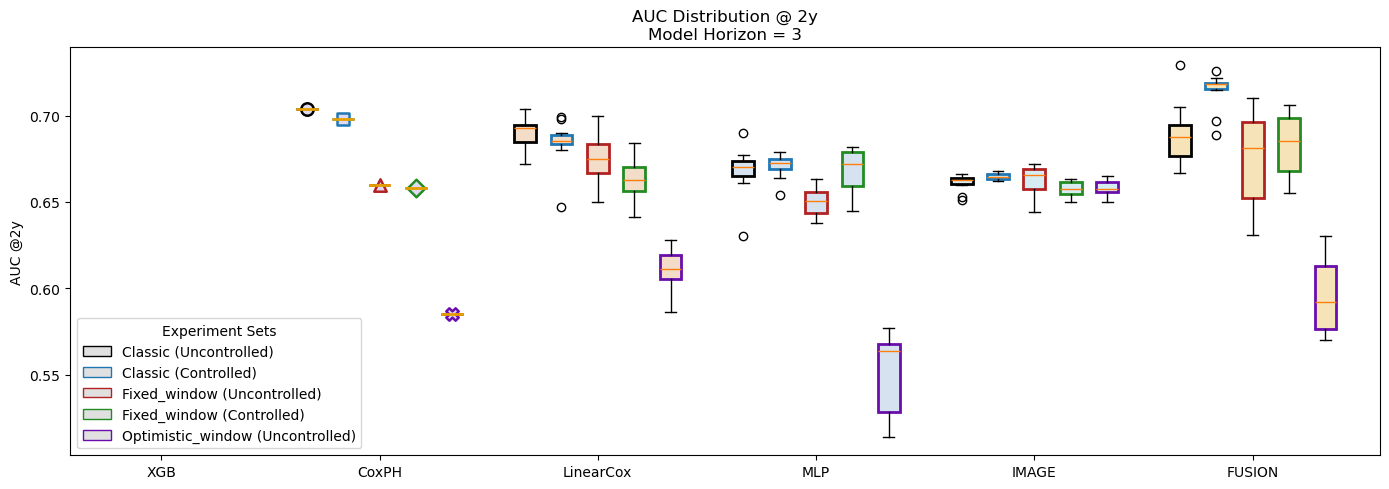

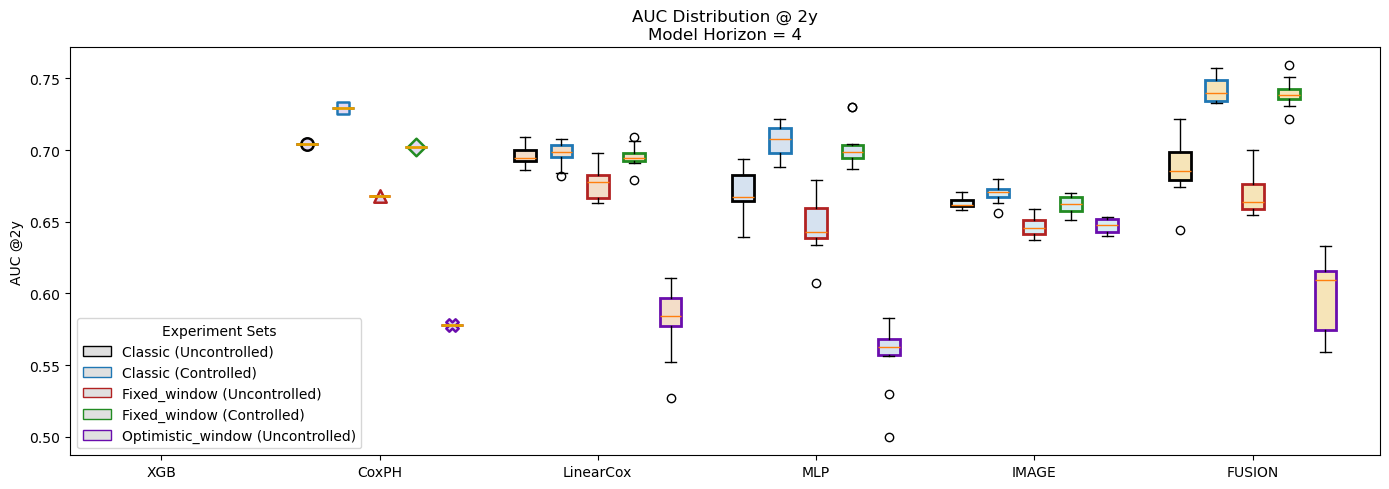

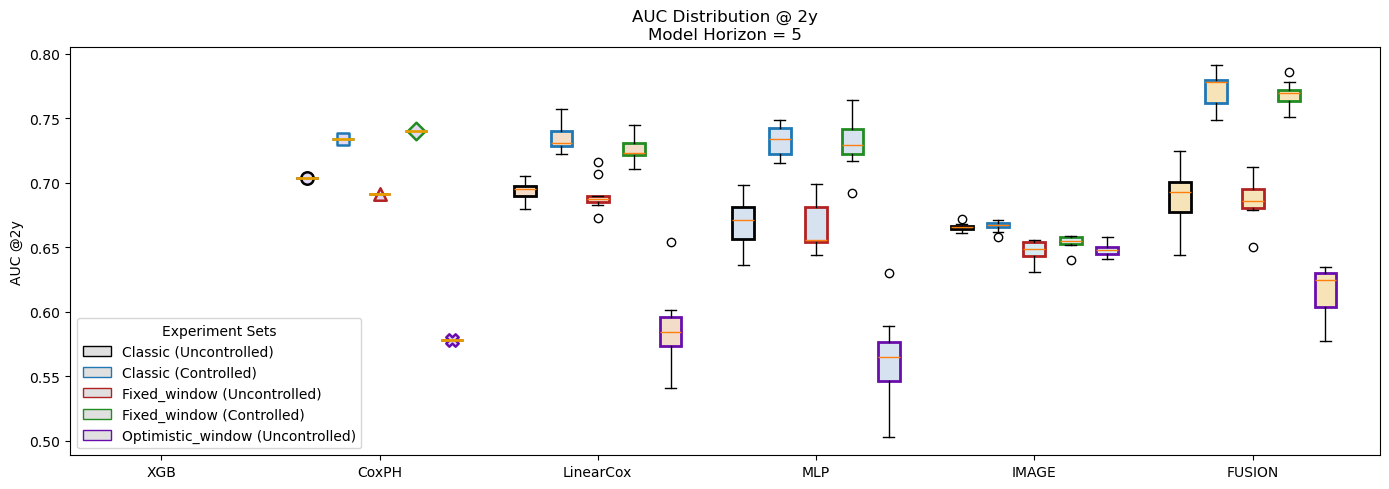

In [21]:
plot_auc_year(df_all, auc_year=2)

### 2.2 tables

In [22]:
get_auc_summary_table(df_all, auc_year=2, model_horizon=4)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,None,None,None
1,CoxPH,"(0.704, 0.704, 0.704)","(0.729, 0.729, 0.729)","(0.668, 0.668, 0.668)","(0.702, 0.702, 0.702)","(0.578, 0.578, 0.578)"
2,LinearCox,"(0.6925, 0.6945, 0.7)","(0.695, 0.6985, 0.7032)","(0.6665, 0.678, 0.6828)","(0.6922, 0.6945, 0.6978)","(0.577, 0.5845, 0.5968)"
3,MLP,"(0.6642, 0.667, 0.6828)","(0.6978, 0.7075, 0.7152)","(0.6385, 0.6425, 0.6595)","(0.6945, 0.6985, 0.7032)","(0.5568, 0.5625, 0.568)"
4,IMAGE,"(0.661, 0.6615, 0.6655)","(0.667, 0.671, 0.673)","(0.6415, 0.6455, 0.6515)","(0.6575, 0.6625, 0.667)","(0.6425, 0.648, 0.652)"
5,FUSION,"(0.6792, 0.6855, 0.6988)","(0.7342, 0.74, 0.749)","(0.659, 0.6635, 0.6765)","(0.7358, 0.7385, 0.7425)","(0.5745, 0.609, 0.6158)"


In [23]:
get_auc_summary_table(df_all, auc_year=2, model_horizon=5)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,None,None,None
1,CoxPH,"(0.704, 0.704, 0.704)","(0.734, 0.734, 0.734)","(0.691, 0.691, 0.691)","(0.74, 0.74, 0.74)","(0.578, 0.578, 0.578)"
2,LinearCox,"(0.69, 0.695, 0.6978)","(0.7282, 0.731, 0.74)","(0.685, 0.6875, 0.69)","(0.7212, 0.723, 0.731)","(0.5732, 0.5845, 0.5955)"
3,MLP,"(0.6562, 0.671, 0.681)","(0.7222, 0.734, 0.7422)","(0.654, 0.6555, 0.6815)","(0.722, 0.729, 0.7415)","(0.5465, 0.565, 0.5765)"
4,IMAGE,"(0.6642, 0.6655, 0.6668)","(0.666, 0.667, 0.669)","(0.643, 0.6485, 0.6538)","(0.6522, 0.655, 0.6578)","(0.6448, 0.648, 0.6505)"
5,FUSION,"(0.6772, 0.693, 0.7008)","(0.762, 0.778, 0.7798)","(0.6805, 0.686, 0.695)","(0.7632, 0.7695, 0.7718)","(0.6038, 0.6245, 0.6298)"


### 2.3 Analysis

#### 2.3.1 model horizon analysis

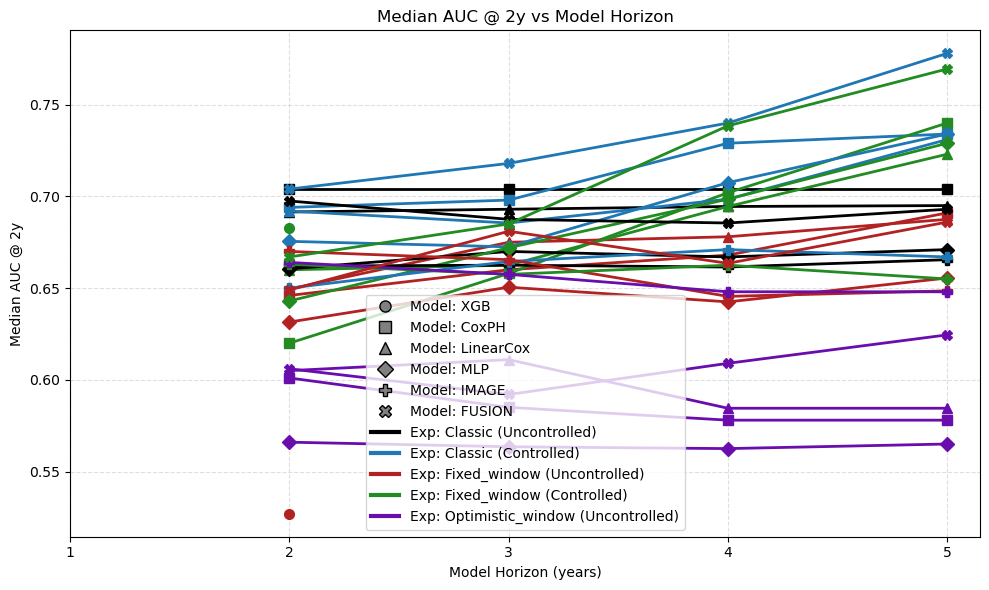

In [24]:
plot_median_auc_trend(df_all, auc_year=2, concise_legend=True)

We observe a different pattern for `Optimistic_window_survival`: it did not improve as model horizon increase, but decrease instead.

- **Reason**: In `optimistic_window_survival`, negative cases have their follow-up time capped at
the training horizon. As the horizon increases, an **increasing** number of censored
patients collapse to the **same duration value**, eliminating censor-time
heterogeneity. Consequently, extending the training horizon does **not introduce
additional temporal ordering information**. Instead, it removes **more** exactly the
structure survival models rely on to distinguish relative risk at longer horizons.
As a result, performance under optimistic-window labeling remains flat or even
degrades as the horizon increases.

- **Why Fusion Models Mitigate This Effect:** Fusion models remain robust under optimistic-window labeling because they rely less
on duration-based supervision and more on **feature expressiveness**, particularly
from imaging embeddings. Imaging features capture structural disease burden and risk
patterns that are not strictly tied to censor-time ordering. By combining imaging
and clinical features, fusion models partially compensate for the loss of temporal
information, allowing performance to continue improving despite weak duration
supervision.

- **Why This Effect Appears Only for AUC@2–5y:** At AUC@1y, censor-time heterogeneity plays a limited role, since most duration
differences lie outside the 1-year evaluation window. However, for AUC@2–5y,
effective discrimination increasingly depends on fine-grained ordering of follow-up
times relative to the event horizon. Optimistic-window labeling cannot support this
ordering, leading to stagnation, while labeling methods that preserve censor-time
heterogeneity continue to improve.

#### 2.3.2 controlled experiemnt analysis (same, skipped)

#### 2.3.3 Uncontrolled labeling analysis

In [25]:
import numpy as np
import pandas as pd

AUC_COL = "AUC @1y"
HORIZON = 5
MODELS = df_all["Model"].unique()

rows_1y_h5 = []

for model in MODELS:
    row = {"Model": model}

    # XGB special case
    if model == "XGB":
        df_fixed = df_all[
            (df_all["Model"] == "XGB") &
            (df_all["label_method"] == "fixed_window_survival") &
            (df_all["controlled_experiment"] == False) &
            (df_all["horizon_year"] == HORIZON)
        ]
        vals = df_fixed[AUC_COL].dropna().values if AUC_COL in df_fixed.columns else []
        row["fixed_window_survival"] = np.median(vals) if len(vals) > 0 else np.nan
        row["optimistic_window_survival"] = np.nan
    else:
        for label in ["fixed_window_survival", "optimistic_window_survival"]:
            df_m = df_all[
                (df_all["Model"] == model) &
                (df_all["label_method"] == label) &
                (df_all["controlled_experiment"] == False) &
                (df_all["horizon_year"] == HORIZON)
            ]
            vals = df_m[AUC_COL].dropna().values if AUC_COL in df_m.columns else []
            row[label] = np.median(vals) if len(vals) > 0 else np.nan

    rows_1y_h5.append(row)

auc1y_uncontrolled_h5_df = pd.DataFrame(rows_1y_h5).set_index("Model")
auc1y_uncontrolled_h5_df


,fixed_window_survival,optimistic_window_survival
Model,,
CoxPH,0.6080,0.5900
LinearCox,0.6065,0.6165
MLP,0.5585,0.6020
IMAGE,0.6975,0.6910
FUSION,0.6230,0.6810
XGB,NaN,NaN


In [26]:
AUC_COL = "AUC @2y"

rows_2y_h5 = []

for model in MODELS:
    row = {"Model": model}

    if model == "XGB":
        df_fixed = df_all[
            (df_all["Model"] == "XGB") &
            (df_all["label_method"] == "fixed_window_survival") &
            (df_all["controlled_experiment"] == False) &
            (df_all["horizon_year"] == HORIZON)
        ]
        vals = df_fixed[AUC_COL].dropna().values if AUC_COL in df_fixed.columns else []
        row["fixed_window_survival"] = np.median(vals) if len(vals) > 0 else np.nan
        row["optimistic_window_survival"] = np.nan
    else:
        for label in ["fixed_window_survival", "optimistic_window_survival"]:
            df_m = df_all[
                (df_all["Model"] == model) &
                (df_all["label_method"] == label) &
                (df_all["controlled_experiment"] == False) &
                (df_all["horizon_year"] == HORIZON)
            ]
            vals = df_m[AUC_COL].dropna().values if AUC_COL in df_m.columns else []
            row[label] = np.median(vals) if len(vals) > 0 else np.nan

    rows_2y_h5.append(row)

auc2y_uncontrolled_h5_df = pd.DataFrame(rows_2y_h5).set_index("Model")
auc2y_uncontrolled_h5_df


,fixed_window_survival,optimistic_window_survival
Model,,
CoxPH,0.6910,0.5780
LinearCox,0.6875,0.5845
MLP,0.6555,0.5650
IMAGE,0.6485,0.6480
FUSION,0.6860,0.6245
XGB,NaN,NaN


In `Uncontrolled` experiemnts, `fixed_window_survival` consistently performed better than `Optimistic_window_survival` for `AUC@2–5y`. This is different from `AUC@1y`.

Recap of two label method, in terms of duration.
- **Optimistic-window labeling collapses censoring times.**  
  Nearly all negative cases have their processed duration set exactly to the horizon (e.g., 3 years), eliminating almost all censor-time heterogeneity.

- **Fixed-window labeling preserves censor-time heterogeneity.**  
  Negative cases retain their original follow-up durations, producing a wide and continuous distribution of censoring times from near 0 up to the horizon.

Analysis of previous plot:
- most censor-time variability is concentrated below 1 year. Beyond the first year, the density of durations becomes sparse and relatively flat.

At longer evaluation horizons:

- The evaluation window overlaps more meaningfully with censor-time variation.
- Differences such as being censored at 0.8 years versus 2.5 years become informative for whether a patient is likely to remain CP-free within 2–5 years.
- Fixed-window labeling allows survival models to exploit this ordering, while optimistic-window labeling removes it entirely (Capping the duration will erase this difference among patients, offering less information.).

Therefore, the benefit of preserving censor-time heterogeneity becomes increasingly pronounced at mid- and long-term horizons.

Summary

- Fixed-window labeling preserves censor-time heterogeneity that is useful for survival modeling.
- At AUC@1y, most of this heterogeneity is either outside the evaluation window or weakly informative, explaining the diminished performance gap.
- At AUC@2–5y, censor-time heterogeneity aligns well with the evaluation objective, leading to consistently improved discrimination.

Conclusion:
> we will select best models for `fixed_window_survival` models.


________

#### 2.3.4 labeling analysis

Now we can see consistently, models trained with
`classic_survival` consistently outperform those trained with
`fixed_window_survival` and `Optimistic_window_survival`, in both controlled and uncontrolled settings. (Except for `AUC@4y` in model horizon 4)

________

#### 2.3.4 Model selection

- best models for AUC@2y:
    - (FUSION,classic_survival,True,5) (0.762, 0.778, 0.7798)	

________

________

## 3. AUC@3y

### 3.1 plots

[DEBUG] AUC@3: plotting horizons → [3, 4, 5]


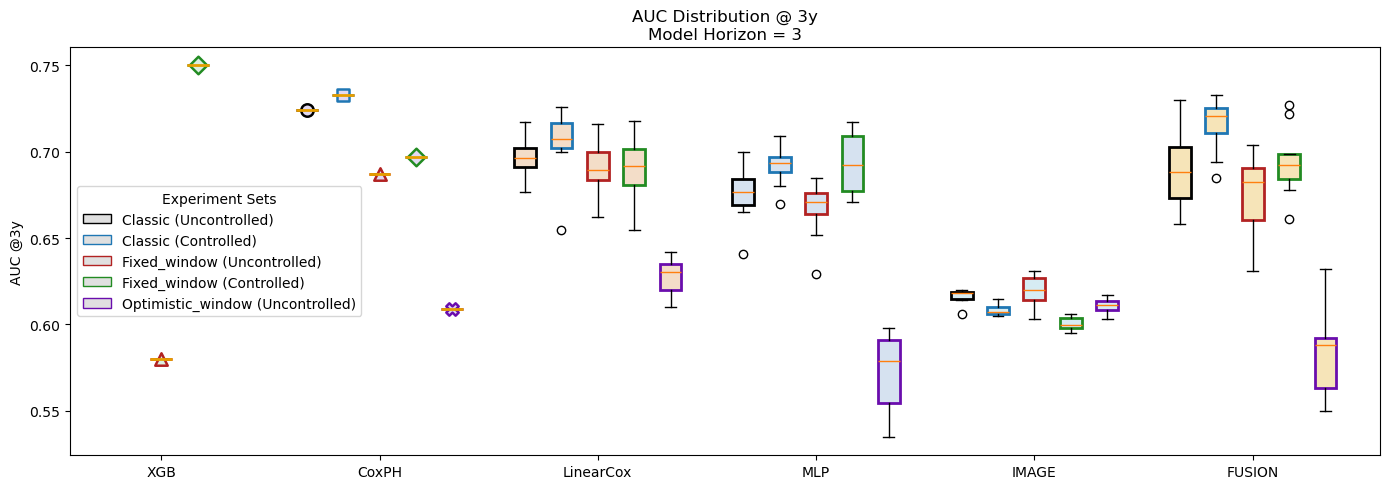

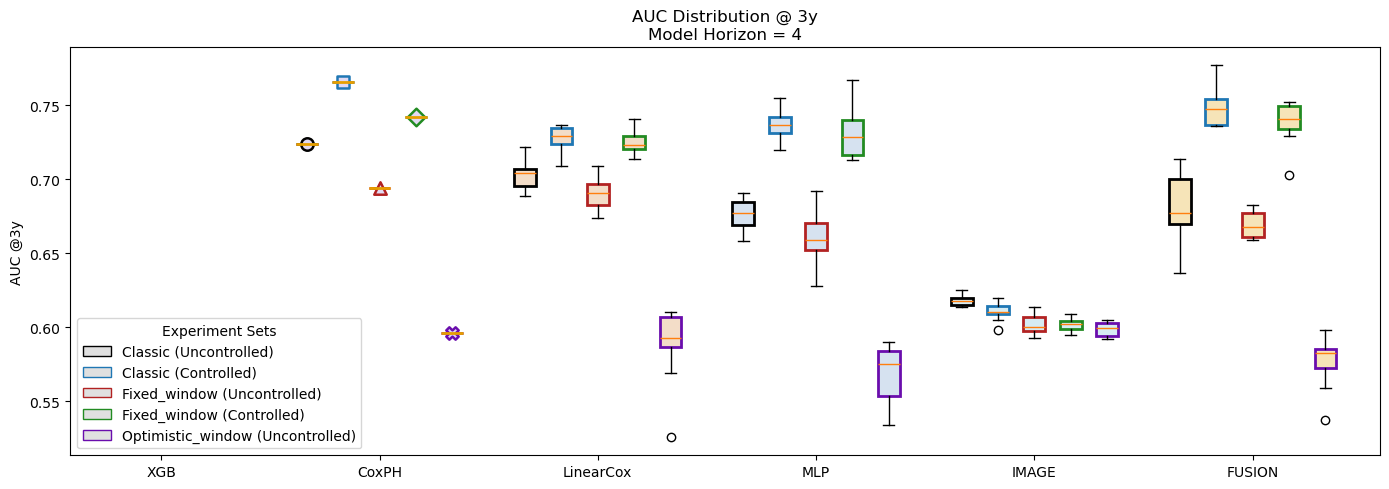

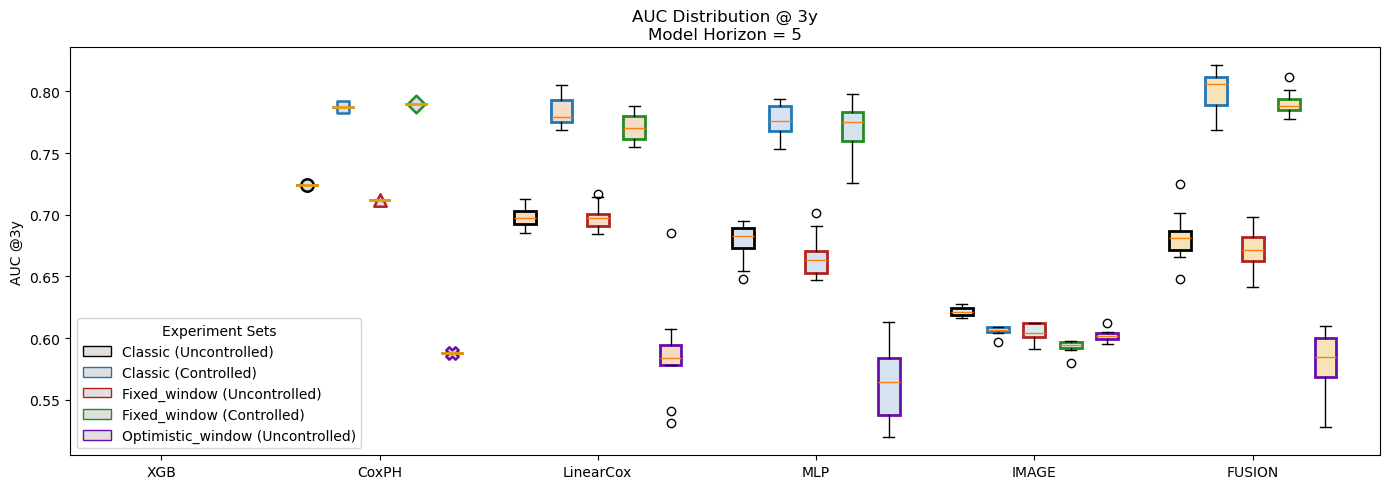

In [27]:
plot_auc_year(df_all, auc_year=3)

### 3.2 tables

In [28]:
get_auc_summary_table(df_all, auc_year=3, model_horizon=4)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,None,None,None
1,CoxPH,"(0.724, 0.724, 0.724)","(0.766, 0.766, 0.766)","(0.694, 0.694, 0.694)","(0.742, 0.742, 0.742)","(0.596, 0.596, 0.596)"
2,LinearCox,"(0.6952, 0.7045, 0.707)","(0.724, 0.7295, 0.7345)","(0.6828, 0.6905, 0.697)","(0.7205, 0.7235, 0.729)","(0.5865, 0.5925, 0.6072)"
3,MLP,"(0.669, 0.6775, 0.685)","(0.7315, 0.737, 0.742)","(0.6525, 0.659, 0.6705)","(0.7162, 0.7285, 0.74)","(0.5535, 0.5755, 0.5838)"
4,IMAGE,"(0.6152, 0.6175, 0.62)","(0.6092, 0.6105, 0.6145)","(0.5975, 0.6, 0.607)","(0.5985, 0.6025, 0.6045)","(0.594, 0.5995, 0.6028)"
5,FUSION,"(0.67, 0.677, 0.7)","(0.737, 0.7475, 0.7545)","(0.6608, 0.6675, 0.677)","(0.734, 0.7405, 0.7498)","(0.5725, 0.5825, 0.585)"


In [29]:
get_auc_summary_table(df_all, auc_year=3, model_horizon=5)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,None,None,None
1,CoxPH,"(0.724, 0.724, 0.724)","(0.787, 0.787, 0.787)","(0.712, 0.712, 0.712)","(0.79, 0.79, 0.79)","(0.588, 0.588, 0.588)"
2,LinearCox,"(0.6922, 0.6975, 0.703)","(0.7752, 0.7795, 0.793)","(0.691, 0.697, 0.7005)","(0.7615, 0.77, 0.78)","(0.5782, 0.584, 0.5948)"
3,MLP,"(0.6732, 0.683, 0.6895)","(0.7675, 0.776, 0.7882)","(0.6528, 0.6635, 0.6708)","(0.7598, 0.775, 0.7832)","(0.5378, 0.5645, 0.5835)"
4,IMAGE,"(0.619, 0.6215, 0.6245)","(0.605, 0.6065, 0.609)","(0.601, 0.6045, 0.612)","(0.5922, 0.5945, 0.5968)","(0.5992, 0.6015, 0.6038)"
5,FUSION,"(0.6718, 0.6815, 0.6865)","(0.7892, 0.806, 0.8115)","(0.6625, 0.6715, 0.682)","(0.785, 0.7885, 0.7938)","(0.5685, 0.5845, 0.6)"


### 3.3 Analysis

Similar pattern as `AUC@2y`, skipped analysis.

- best models for `AUC@3y`:
    - (FUSION,classic_survival,True,5) (0.7892, 0.806, 0.8115)

________

________

## 4. AUC@4y

### 4.1 plots

[DEBUG] AUC@4: plotting horizons → [4, 5]


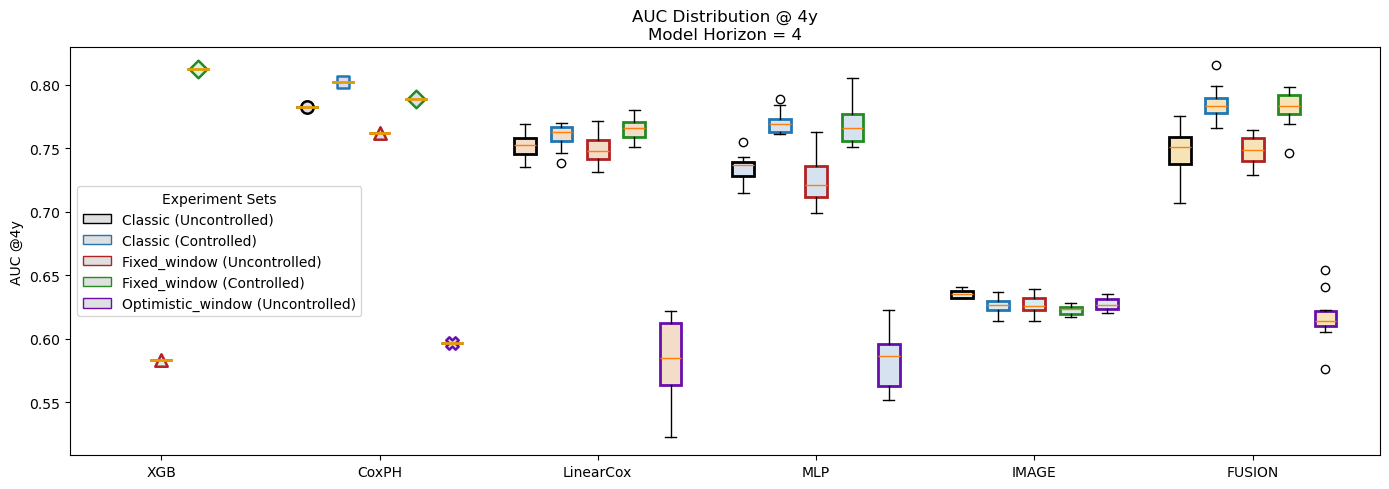

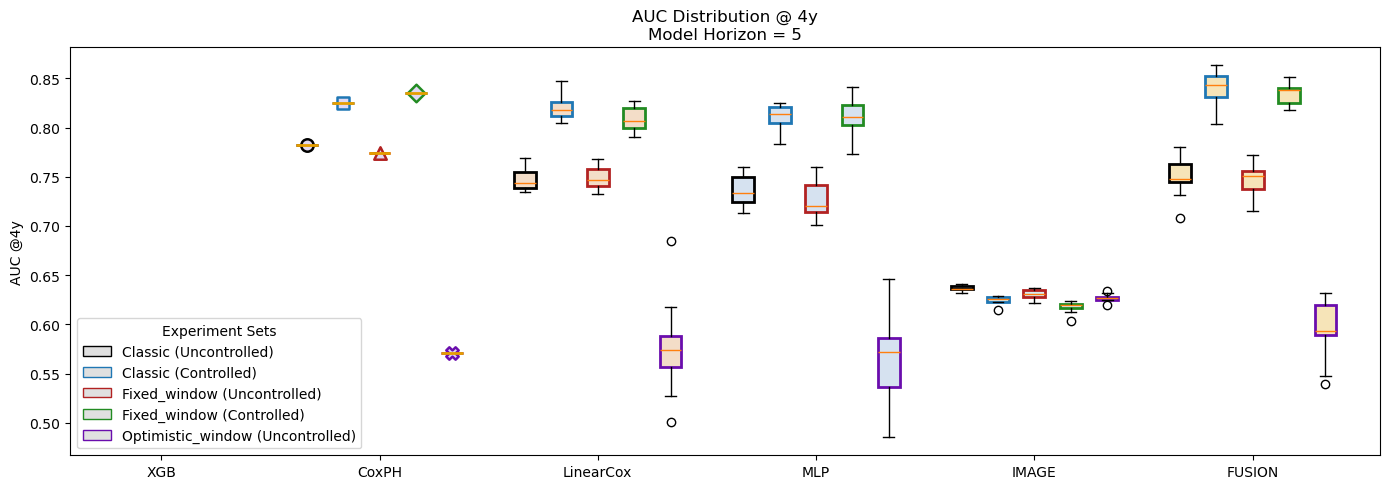

In [30]:
plot_auc_year(df_all, auc_year=4)

### 4.2 Tables

In [31]:
get_auc_summary_table(df_all, auc_year=4, model_horizon=4)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,"(0.583, 0.583, 0.583)","(0.812, 0.812, 0.812)",None
1,CoxPH,"(0.782, 0.782, 0.782)","(0.802, 0.802, 0.802)","(0.762, 0.762, 0.762)","(0.789, 0.789, 0.789)","(0.597, 0.597, 0.597)"
2,LinearCox,"(0.7455, 0.7525, 0.758)","(0.756, 0.7625, 0.7665)","(0.7412, 0.7475, 0.7568)","(0.759, 0.7655, 0.7708)","(0.564, 0.585, 0.6122)"
3,MLP,"(0.7282, 0.737, 0.7388)","(0.763, 0.769, 0.773)","(0.7112, 0.721, 0.7358)","(0.7555, 0.766, 0.7768)","(0.5632, 0.5865, 0.596)"
4,IMAGE,"(0.6322, 0.635, 0.6378)","(0.6228, 0.6265, 0.63)","(0.623, 0.626, 0.632)","(0.6192, 0.6235, 0.6248)","(0.6238, 0.627, 0.6315)"
5,FUSION,"(0.7375, 0.7505, 0.759)","(0.7775, 0.7835, 0.7895)","(0.7398, 0.7485, 0.758)","(0.7768, 0.783, 0.7918)","(0.61, 0.614, 0.622)"


In [32]:
get_auc_summary_table(df_all, auc_year=4, model_horizon=5)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,None,None,None
1,CoxPH,"(0.782, 0.782, 0.782)","(0.825, 0.825, 0.825)","(0.774, 0.774, 0.774)","(0.835, 0.835, 0.835)","(0.571, 0.571, 0.571)"
2,LinearCox,"(0.7385, 0.7435, 0.755)","(0.8115, 0.8175, 0.8258)","(0.7402, 0.7465, 0.7575)","(0.7995, 0.807, 0.8195)","(0.5568, 0.574, 0.588)"
3,MLP,"(0.7242, 0.734, 0.7498)","(0.8042, 0.8135, 0.8205)","(0.714, 0.7205, 0.742)","(0.803, 0.811, 0.8232)","(0.5362, 0.572, 0.5868)"
4,IMAGE,"(0.636, 0.6365, 0.639)","(0.6232, 0.6255, 0.6275)","(0.6282, 0.6305, 0.635)","(0.6165, 0.62, 0.6208)","(0.6252, 0.6265, 0.628)"
5,FUSION,"(0.7442, 0.748, 0.7628)","(0.8305, 0.843, 0.8525)","(0.7375, 0.7505, 0.7555)","(0.8248, 0.8385, 0.8398)","(0.5895, 0.593, 0.6198)"


### 4.3 Analysis

Similar pattern as `AUC@2y`, skipped analysis.

- best models for `AUC@4y`:
    - (FUSION,classic_survival,True,5) (0.8305, 0.843, 0.8525)

________

________

## 5. AUC@5y

### 5.1 plots

[DEBUG] AUC@5: plotting horizons → [5]


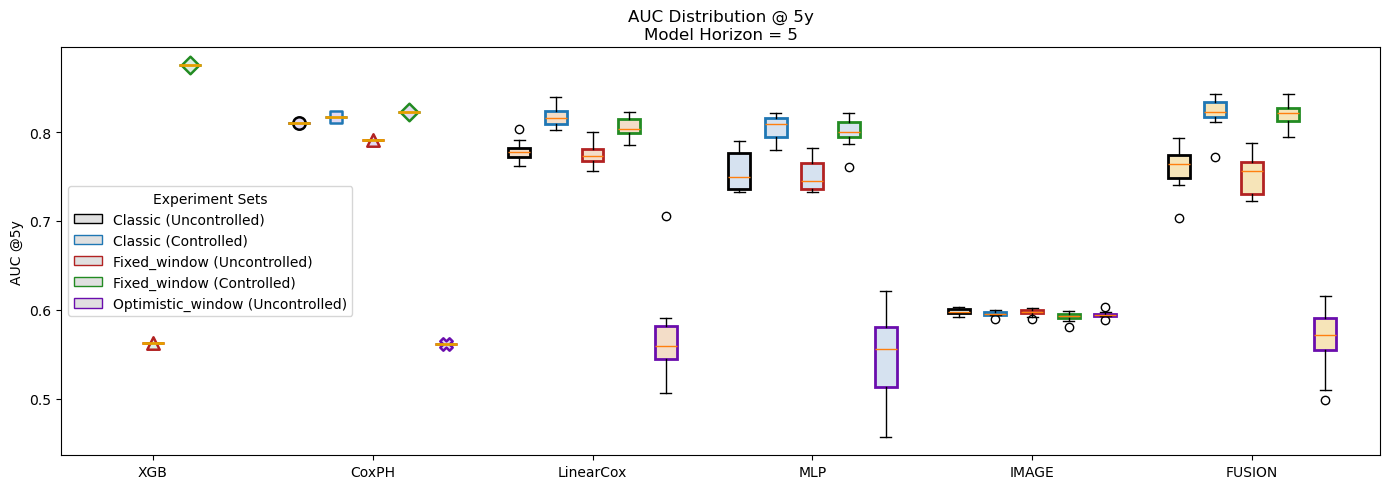

In [33]:
plot_auc_year(df_all, auc_year=5)

### 5.2 Tables

In [34]:
get_auc_summary_table(df_all, auc_year=5, model_horizon=5)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,"(0.563, 0.563, 0.563)","(0.875, 0.875, 0.875)",None
1,CoxPH,"(0.81, 0.81, 0.81)","(0.817, 0.817, 0.817)","(0.791, 0.791, 0.791)","(0.823, 0.823, 0.823)","(0.561, 0.561, 0.561)"
2,LinearCox,"(0.7725, 0.7775, 0.7825)","(0.809, 0.8155, 0.824)","(0.7675, 0.773, 0.781)","(0.7985, 0.8035, 0.8152)","(0.5445, 0.5595, 0.5812)"
3,MLP,"(0.7362, 0.7495, 0.7765)","(0.794, 0.809, 0.8162)","(0.7362, 0.745, 0.7652)","(0.794, 0.8, 0.8115)","(0.5135, 0.5555, 0.5808)"
4,IMAGE,"(0.596, 0.597, 0.6005)","(0.5942, 0.595, 0.5975)","(0.596, 0.597, 0.5998)","(0.5905, 0.593, 0.5955)","(0.593, 0.594, 0.5948)"
5,FUSION,"(0.7488, 0.7645, 0.7748)","(0.8165, 0.823, 0.8338)","(0.7305, 0.7565, 0.7662)","(0.8128, 0.821, 0.8268)","(0.5548, 0.572, 0.5905)"


### 5.3 Analysis

Similar pattern as `AUC@2y`, skipped analysis.

- best models for `AUC@4y`:
    - (FUSION,classic_survival,True,5) (0.8165, 0.823, 0.8338)
    - (XGB,fixed_window_survival,True,5) (0.875, 0.875, 0.875)	

________

________

## 6. Extra Analysis

### 6.1 Image model analysis

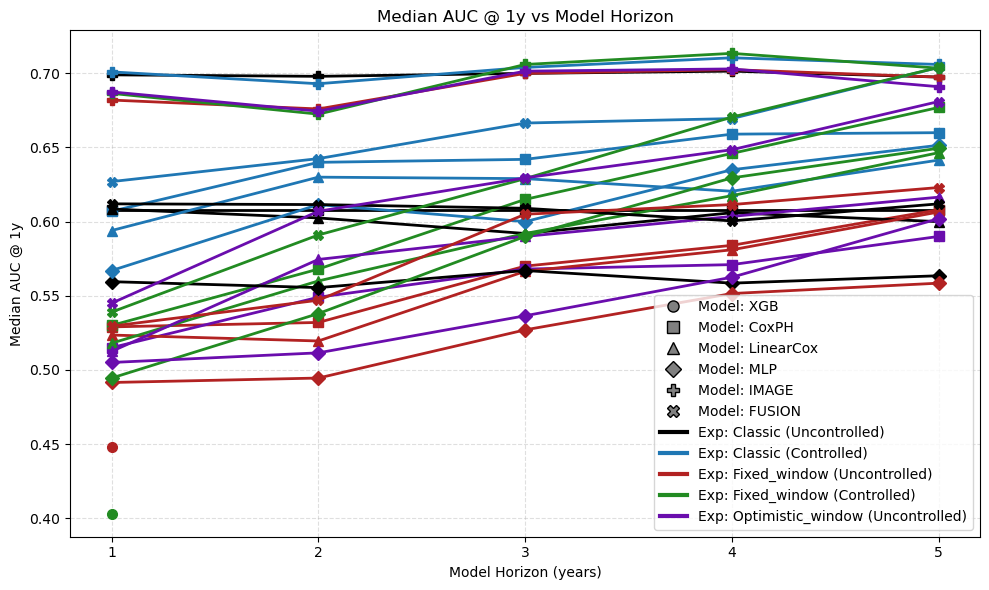

In [35]:
plot_median_auc_trend(df_all, auc_year=1, concise_legend=True)

We observed that increasing training horizon doesn’t help `IMAGE` (image-only) much.

- Increasing the training horizon changes the **label definition** (e.g., predicting
CP within 2 years versus within 5 years), but it does not change the information
contained in the image features. Although image embeddings are extracted from
multiple CT scans with relative timing, they primarily encode the **current disease
state and accumulated structural severity**, rather than explicit information about
how many years remain until CP onset. As a result, extending the training horizon alters the supervision signal without
introducing new feature structure that image-only models can exploit. 

### 6.2 Fusion analysis

In [36]:
# ------------------------------
# Best experiment setup
# ------------------------------
BEST_LABEL = "classic_survival"
BEST_CTRL = True
BEST_HORIZON = 5

MODELS_OF_INTEREST = ["IMAGE", "MLP", "FUSION"]
AUC_YEARS = [1, 2, 3, 4, 5]

rows = []

for model in MODELS_OF_INTEREST:
    df_m = df_all[
        (df_all["Model"] == model) &
        (df_all["label_method"] == BEST_LABEL) &
        (df_all["controlled_experiment"] == BEST_CTRL) &
        (df_all["horizon_year"] == BEST_HORIZON)
    ]

    if df_m.empty:
        continue

    row = {"Model": model}

    for n in AUC_YEARS:
        col = f"AUC @{n}y"
        if col in df_m.columns:
            vals = df_m[col].dropna().values
            row[f"AUC@{n}y"] = np.median(vals) if len(vals) > 0 else np.nan
        else:
            row[f"AUC@{n}y"] = np.nan

    rows.append(row)

# ------------------------------
# Final table
# ------------------------------
auc_table = pd.DataFrame(rows).set_index("Model")
auc_table

,AUC@1y,AUC@2y,AUC@3y,AUC@4y,AUC@5y
Model,,,,,
IMAGE,0.7060,0.667,0.6065,0.6255,0.595
MLP,0.6515,0.734,0.7760,0.8135,0.809
FUSION,0.7040,0.778,0.8060,0.8430,0.823


Under the best-performing configuration (`classic_survival`, controlled, training
horizon = 5 years), the relative strengths of `IMAGE` and `MLP` models differ across
evaluation horizons. `IMAGE` performs relatively well at short horizons but degrades
at longer horizons, while `MLP` shows the opposite pattern, with stronger performance
at mid- to long-term horizons. (!!!Noticing that **degrade** and **stronger performance** here doesn't mean comparing `AUC@1y` and `AUC@5y`. Instead they are comapred within their `AUC@ny` groups)

Across all evaluation horizons, the `FUSION` model consistently matches or exceeds
the stronger of the two individual modalities at the same horizon. When `IMAGE`
performance is higher and `MLP` is lower, fusion maintains strong discrimination;
conversely, when `MLP` dominates and `IMAGE` weakens, fusion continues to perform well.
This suggests that the fusion model effectively reweights information from imaging
and clinical features depending on the evaluation context, leading to robust
performance without relying on a single modality.

### 6.3 Model analysis

In [37]:
get_auc_summary_table(df_all, auc_year=2, model_horizon=5)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,None,None,None
1,CoxPH,"(0.704, 0.704, 0.704)","(0.734, 0.734, 0.734)","(0.691, 0.691, 0.691)","(0.74, 0.74, 0.74)","(0.578, 0.578, 0.578)"
2,LinearCox,"(0.69, 0.695, 0.6978)","(0.7282, 0.731, 0.74)","(0.685, 0.6875, 0.69)","(0.7212, 0.723, 0.731)","(0.5732, 0.5845, 0.5955)"
3,MLP,"(0.6562, 0.671, 0.681)","(0.7222, 0.734, 0.7422)","(0.654, 0.6555, 0.6815)","(0.722, 0.729, 0.7415)","(0.5465, 0.565, 0.5765)"
4,IMAGE,"(0.6642, 0.6655, 0.6668)","(0.666, 0.667, 0.669)","(0.643, 0.6485, 0.6538)","(0.6522, 0.655, 0.6578)","(0.6448, 0.648, 0.6505)"
5,FUSION,"(0.6772, 0.693, 0.7008)","(0.762, 0.778, 0.7798)","(0.6805, 0.686, 0.695)","(0.7632, 0.7695, 0.7718)","(0.6038, 0.6245, 0.6298)"


In [38]:
get_auc_summary_table(df_all, auc_year=3, model_horizon=5)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,None,None,None
1,CoxPH,"(0.724, 0.724, 0.724)","(0.787, 0.787, 0.787)","(0.712, 0.712, 0.712)","(0.79, 0.79, 0.79)","(0.588, 0.588, 0.588)"
2,LinearCox,"(0.6922, 0.6975, 0.703)","(0.7752, 0.7795, 0.793)","(0.691, 0.697, 0.7005)","(0.7615, 0.77, 0.78)","(0.5782, 0.584, 0.5948)"
3,MLP,"(0.6732, 0.683, 0.6895)","(0.7675, 0.776, 0.7882)","(0.6528, 0.6635, 0.6708)","(0.7598, 0.775, 0.7832)","(0.5378, 0.5645, 0.5835)"
4,IMAGE,"(0.619, 0.6215, 0.6245)","(0.605, 0.6065, 0.609)","(0.601, 0.6045, 0.612)","(0.5922, 0.5945, 0.5968)","(0.5992, 0.6015, 0.6038)"
5,FUSION,"(0.6718, 0.6815, 0.6865)","(0.7892, 0.806, 0.8115)","(0.6625, 0.6715, 0.682)","(0.785, 0.7885, 0.7938)","(0.5685, 0.5845, 0.6)"


In [39]:
get_auc_summary_table(df_all, auc_year=4, model_horizon=5)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,None,None,None
1,CoxPH,"(0.782, 0.782, 0.782)","(0.825, 0.825, 0.825)","(0.774, 0.774, 0.774)","(0.835, 0.835, 0.835)","(0.571, 0.571, 0.571)"
2,LinearCox,"(0.7385, 0.7435, 0.755)","(0.8115, 0.8175, 0.8258)","(0.7402, 0.7465, 0.7575)","(0.7995, 0.807, 0.8195)","(0.5568, 0.574, 0.588)"
3,MLP,"(0.7242, 0.734, 0.7498)","(0.8042, 0.8135, 0.8205)","(0.714, 0.7205, 0.742)","(0.803, 0.811, 0.8232)","(0.5362, 0.572, 0.5868)"
4,IMAGE,"(0.636, 0.6365, 0.639)","(0.6232, 0.6255, 0.6275)","(0.6282, 0.6305, 0.635)","(0.6165, 0.62, 0.6208)","(0.6252, 0.6265, 0.628)"
5,FUSION,"(0.7442, 0.748, 0.7628)","(0.8305, 0.843, 0.8525)","(0.7375, 0.7505, 0.7555)","(0.8248, 0.8385, 0.8398)","(0.5895, 0.593, 0.6198)"


In [40]:
get_auc_summary_table(df_all, auc_year=5, model_horizon=5)

,Model,"classic_survival,False","classic_survival,True","fixed_window_survival,False","fixed_window_survival,True","optimistic_window_survival,False"
0,XGB,None,None,"(0.563, 0.563, 0.563)","(0.875, 0.875, 0.875)",None
1,CoxPH,"(0.81, 0.81, 0.81)","(0.817, 0.817, 0.817)","(0.791, 0.791, 0.791)","(0.823, 0.823, 0.823)","(0.561, 0.561, 0.561)"
2,LinearCox,"(0.7725, 0.7775, 0.7825)","(0.809, 0.8155, 0.824)","(0.7675, 0.773, 0.781)","(0.7985, 0.8035, 0.8152)","(0.5445, 0.5595, 0.5812)"
3,MLP,"(0.7362, 0.7495, 0.7765)","(0.794, 0.809, 0.8162)","(0.7362, 0.745, 0.7652)","(0.794, 0.8, 0.8115)","(0.5135, 0.5555, 0.5808)"
4,IMAGE,"(0.596, 0.597, 0.6005)","(0.5942, 0.595, 0.5975)","(0.596, 0.597, 0.5998)","(0.5905, 0.593, 0.5955)","(0.593, 0.594, 0.5948)"
5,FUSION,"(0.7488, 0.7645, 0.7748)","(0.8165, 0.823, 0.8338)","(0.7305, 0.7565, 0.7662)","(0.8128, 0.821, 0.8268)","(0.5548, 0.572, 0.5905)"


In [41]:
AUC_YEARS = [1, 2, 3, 4, 5]

rows = []

# ------------------------------
# XGBoost (special case)
# ------------------------------
df_xgb = df_all[
    (df_all["Model"] == "XGB") &
    (df_all["label_method"] == "fixed_window_survival") &
    (df_all["controlled_experiment"] == True)
]

row_xgb = {"Model": "XGB"}
for n in AUC_YEARS:
    col = f"AUC @{n}y"
    if col in df_xgb.columns:
        vals = df_xgb[col].dropna().values
        row_xgb[f"AUC@{n}y"] = np.median(vals) if len(vals) > 0 else np.nan
    else:
        row_xgb[f"AUC@{n}y"] = np.nan

rows.append(row_xgb)

# ------------------------------
# Best FUSION model
# ------------------------------
df_fusion = df_all[
    (df_all["Model"] == "FUSION") &
    (df_all["label_method"] == "classic_survival") &
    (df_all["controlled_experiment"] == True) &
    (df_all["horizon_year"] == 5)
]

row_fusion = {"Model": "FUSION"}
for n in AUC_YEARS:
    col = f"AUC @{n}y"
    if col in df_fusion.columns:
        vals = df_fusion[col].dropna().values
        row_fusion[f"AUC@{n}y"] = np.median(vals) if len(vals) > 0 else np.nan
    else:
        row_fusion[f"AUC@{n}y"] = np.nan

rows.append(row_fusion)

# ------------------------------
# Final table
# ------------------------------
auc_compare_table = pd.DataFrame(rows).set_index("Model")
auc_compare_table


,AUC@1y,AUC@2y,AUC@3y,AUC@4y,AUC@5y
Model,,,,,
XGB,0.403,0.683,0.750,0.812,0.875
FUSION,0.704,0.778,0.806,0.843,0.823


- clinical based model has AUCs (CoxPh>LinearCox≈MLP)
- XGBoost shows increasing AUC at longer horizons, reflecting its strength in
  binary window-based classification when more long-term outcomes are observable.
  However, FUSION maintains robust performance across all horizons by integrating
  imaging and clinical information, rather than relying on a single modality.
    - The apparent performance differences across evaluation horizons are partly
driven by substantial changes in class balance, with early horizons exhibiting
severe imbalance that limits learnable signal and increases variance.

Meaningful TP / TN Distribution under Controlled Experiments

| Horizon | Split | True Positives (TP) | True Negatives (TN) | Total Meaningful | TP : TN Ratio |
|--------:|:------|--------------------:|--------------------:|-----------------:|:-------------|
| **1 year** | Train | 41 | 495 | 536 | 1 : 12.1 |
|          | Val   | 13 | 163 | 176 | 1 : 12.5 |
|          | Test  | 13 | 163 | 176 | 1 : 12.5 |
| **3 years** | Train | 102 | 278 | 380 | 1 : 2.7 |
|          | Val   | 34 | 90  | 124 | 1 : 2.6 |
|          | Test  | 38 | 85  | 123 | 1 : 2.2 |
| **5 years** | Train | 128 | 184 | 312 | 1 : 1.4 |
|          | Val   | 45 | 59  | 104 | 1 : 1.3 |
|          | Test  | 46 | 50  | 96  | 1 : 1.1 |


### 6.4 Overall comparison

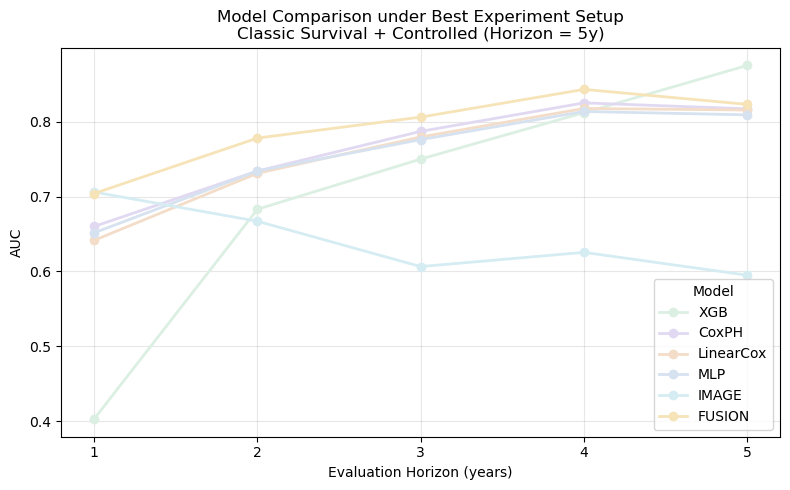

In [42]:
final_plot1()

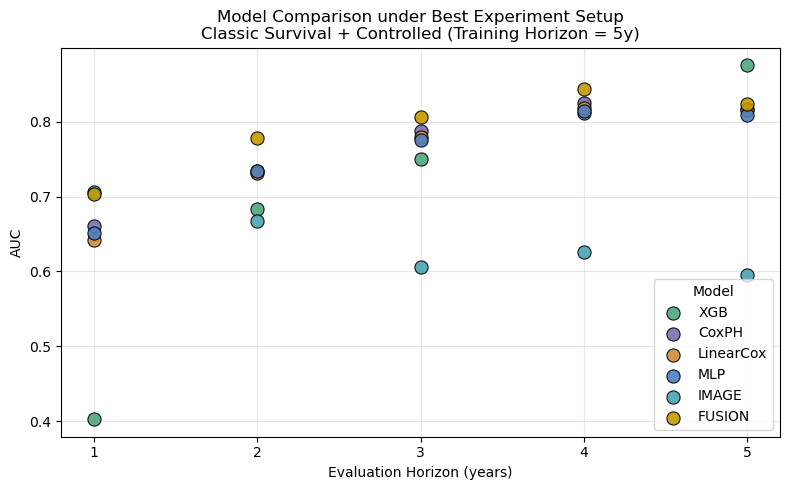

In [43]:
final_plot2()

**NOTE**: We can observe that model has patterns like "AUC@ny decreases as n increases" (`IMAGE`) or "AUC@ny increases as n increases" (`FUSION`) However, the dataset used for evalution gets smaller for larger `n`, so we **cannot** directly compute `AUC@1Y` and `AUC@5Y` for one model or conclude "model is worse/better at longer horizons".

----------

----------

## 7. Conclusion

### 1. Classic survival labeling provides the best overall risk modeling

- `classic_survival` labeling offers the strongest risk analysis and achieves the
  best overall AUC performance across models.
- Although `fixed_window_survival` and `optimistic_window_survival` are more directly
  aligned with the goal of predicting whether a patient develops CP within `n`
  years, their empirical performance is consistently weaker.

### 2. Controlled experiments consistently improve performance

- Models trained under `controlled_experiment=True` consistently outperform their
  uncontrolled counterparts.
- For the current dataset, restricting training to **meaningful datapoints only**
  helps models learn more effectively by removing ambiguous cases.

### 3. Larger training horizons lead to better learning

- When combined with `controlled_experiment=True`, larger training horizons allow
  models to train only on datapoints with known outcomes relative to the specified
  horizon.
- In the best-performing configuration, we use `controlled_experiment=True` with
  a training horizon of **5 years**, meaning that only patients with reliable
  outcome information are included:
  - patients who developed CP at 1.1 or 3.4 years,
  - patients who developed CP after the horizon (e.g., at 5.6 years),
  - or patients with follow-up time exceeding 5 years.
- Since our evaluation focuses on `AUC@1–5y`, this filtering strategy keeps the
  training dataset clean and well-aligned with the evaluation objectives.


--------------

--------------

## 7. Best Model

Although `IMAGE` obtained best (0.7108, 0.7135, 0.72) for `AUC @1y` and `XGB` obtained best (0.875, 0.875, 0.875) for `AUC @5y`, they performed worse in other AUCs. The overall best model will be will be: 


**(FUSION,classic_survival,True,5)**
- **AUC @1y (0.688, 0.704, 0.7172)**
- **AUC @2y (0.762, 0.778, 0.7798)**
- **AUC @3y (0.7892, 0.806, 0.8115)**
- **AUC @4y (0.8305, 0.843, 0.8525)**
- **AUC @5y (0.8165, 0.823, 0.8338)**

Note: (Q1, Median, Q3) for boxplot from 10 training runs.

--------------

--------------

extra note: using `Uncontrolled`, we have
**(FUSION,classic_survival,False,5)**
- **AUC @1y  (0.602, 0.612, 0.6178)**
- **AUC @2y (0.6772, 0.693, 0.7008)**
- **AUC @3y (0.6718, 0.6815, 0.6865)**
- **AUC @4y (0.7442, 0.748, 0.7628)**
- **AUC @5y (0.7488, 0.7645, 0.7748)**